# **Ancient Greek POS Tagger with BERTS**

### **Assignment 6b - Natural Language Processing - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 88.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import average_precision_score

In [3]:
# Make a data directory
import os
os.makedirs("data", exist_ok=True)

# Download the train/dev/test files
!wget -O data/grc_proiel-ud-train.conllu https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-train.conllu
!wget -O data/grc_proiel-ud-dev.conllu   https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-dev.conllu
!wget -O data/grc_proiel-ud-test.conllu  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-test.conllu

# Verify they’re there
!ls -lh data


--2026-01-16 17:18:38--  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-train.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20765815 (20M) [text/plain]
Saving to: ‘data/grc_proiel-ud-train.conllu’

data/grc_proiel-ud- 100%[===================>]  19.80M  --.-KB/s    in 0.1s    

2026-01-16 17:18:39 (145 MB/s) - ‘data/grc_proiel-ud-train.conllu’ saved [20765815/20765815]

--2026-01-16 17:18:39--  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-dev.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.1

In [4]:
def read_conllu(path):
    sentences = []
    words = []
    tags = []

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if words:
                    sentences.append((words, tags))
                    words, tags = [], []
                continue
            if line.startswith("#"):
                continue
            parts = line.split("\t")
            if "-" in parts[0] or "." in parts[0]:
                continue
            word = parts[1]   # FORM
            upos = parts[3]   # UPOS tag
            words.append(word)
            tags.append(upos)

    if words:
        sentences.append((words, tags))

    return sentences

train_path = "data/grc_proiel-ud-train.conllu"
dev_path   = "data/grc_proiel-ud-dev.conllu"
test_path  = "data/grc_proiel-ud-test.conllu"

train_sents = read_conllu(train_path)
dev_sents   = read_conllu(dev_path)
test_sents  = read_conllu(test_path)

print(f"Train sentences: {len(train_sents)}")
print(f"Dev sentences:   {len(dev_sents)}")
print(f"Test sentences:  {len(test_sents)}")
print("Example:", train_sents[0])


Train sentences: 15016
Dev sentences:   1019
Test sentences:  1047
Example: (['Ἡροδότου', 'Ἁλικαρνησσέος', 'ἱστορίης', 'ἀπόδεξις', 'ἥδε', 'ὡς', 'μήτε', 'τὰ', 'γενόμενα', 'ἐξ', 'ἀνθρώπων', 'τῷ', 'χρόνῳ', 'ἐξίτηλα', 'γένηται', 'μήτε', 'ἔργα', 'μεγάλα', 'τε', 'καὶ', 'θωμαστά', 'τὰ', 'μὲν', 'Ἕλλησι', 'τὰ', 'δὲ', 'βαρβάροισι', 'ἀποδεχθέντα', 'ἀκλεᾶ', 'γένηται', 'τά', 'τε', 'ἄλλα', 'καὶ', 'δι’', 'ἣν', 'αἰτίην', 'ἐπολέμησαν', 'ἀλλήλοισι'], ['PROPN', 'NOUN', 'NOUN', 'NOUN', 'PRON', 'SCONJ', 'CCONJ', 'DET', 'VERB', 'ADP', 'NOUN', 'DET', 'NOUN', 'ADJ', 'VERB', 'CCONJ', 'NOUN', 'ADJ', 'CCONJ', 'CCONJ', 'ADJ', 'PRON', 'ADV', 'NOUN', 'PRON', 'ADV', 'NOUN', 'VERB', 'ADJ', 'VERB', 'DET', 'CCONJ', 'PRON', 'CCONJ', 'ADP', 'PRON', 'NOUN', 'VERB', 'PRON'])


In [5]:
from collections import Counter
import numpy as np

def dataset_stats(sentences):
    # sentences: list of (words, tags)
    num_sents = len(sentences)
    lengths = [len(words) for words, tags in sentences]
    all_words = [w for words, tags in sentences for w in words]
    all_tags  = [t for words, tags in sentences for t in tags]
    vocab = set(all_words)
    tagset = set(all_tags)
    return {
        "num_sents": num_sents,
        "num_tokens": len(all_words),
        "avg_sent_len": float(np.mean(lengths)),
        "median_sent_len": float(np.median(lengths)),
        "vocab_size": len(vocab),
        "num_tags": len(tagset),
        "tag_counts": Counter(all_tags),
    }

for name, sents in [("train", train_sents), ("dev", dev_sents), ("test", test_sents)]:
    stats = dataset_stats(sents)
    print(f"{name.upper()} stats:")
    print(f"  sentences:        {stats['num_sents']}")
    print(f"  tokens:           {stats['num_tokens']}")
    print(f"  avg sent length:  {stats['avg_sent_len']:.2f}")
    print(f"  median sent len:  {stats['median_sent_len']:.2f}")
    print(f"  vocab size:       {stats['vocab_size']}")
    print(f"  number of tags:   {stats['num_tags']}")
    print("  most common tags:")
    for tag, c in stats["tag_counts"].most_common(10):
        print(f"    {tag}: {c}")
    print()


TRAIN stats:
  sentences:        15016
  tokens:           187039
  avg sent length:  12.46
  median sent len:  10.00
  vocab size:       30349
  number of tags:   13
  most common tags:
    VERB: 34517
    NOUN: 31424
    DET: 28070
    ADV: 20288
    PRON: 19756
    ADP: 13812
    CCONJ: 12117
    ADJ: 10361
    PROPN: 7745
    SCONJ: 3610

DEV stats:
  sentences:        1019
  tokens:           13652
  avg sent length:  13.40
  median sent len:  11.00
  vocab size:       4541
  number of tags:   13
  most common tags:
    VERB: 2671
    NOUN: 2185
    DET: 2082
    PRON: 1446
    ADV: 1378
    CCONJ: 978
    ADP: 922
    ADJ: 729
    PROPN: 618
    SCONJ: 257

TEST stats:
  sentences:        1047
  tokens:           13314
  avg sent length:  12.72
  median sent len:  11.00
  vocab size:       4495
  number of tags:   13
  most common tags:
    VERB: 2494
    NOUN: 2209
    DET: 2006
    PRON: 1427
    ADV: 1416
    CCONJ: 1011
    ADP: 885
    ADJ: 752
    PROPN: 494
    AUX: 248



In [6]:
from gensim.models import Word2Vec
from collections import Counter
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def build_word_vocab(sentences, min_freq=1):
    """
    sentences: list of (words, tags)
    returns: word2idx, idx2word
    """
    counter = Counter()
    for words, tags in sentences:
        counter.update(words)

    word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    idx2word = [PAD_TOKEN, UNK_TOKEN]

    for w, c in counter.items():
        if c >= min_freq:
            if w not in word2idx:  # avoid duplicates
                word2idx[w] = len(idx2word)
                idx2word.append(w)

    return word2idx, idx2word

def build_tag_vocab(sentences):
    """
    sentences: list of (words, tags)
    returns: tag2idx, idx2tag
    """
    tagset = set()
    for words, tags in sentences:
        tagset.update(tags)

    tag2idx = {}
    idx2tag = []
    for t in sorted(tagset):  # sorted for reproducible order
        tag2idx[t] = len(idx2tag)
        idx2tag.append(t)

    return tag2idx, idx2tag

# ---- Build vocabularies ----
word2idx, idx2word = build_word_vocab(train_sents, min_freq=1)
tag2idx, idx2tag   = build_tag_vocab(train_sents)

print("Vocab size:", len(word2idx))
print("Number of tags:", len(tag2idx))
print("Tags:", tag2idx)

pad_idx = word2idx[PAD_TOKEN]

# ---- Train Word2Vec on training sentences ----
all_tokenized_sents = [words for (words, tags) in train_sents]

w2v_dim = 100   # must match the CNN/RNN/MLP config emb_dim
w2v_model = Word2Vec(
    sentences=all_tokenized_sents,
    vector_size=w2v_dim,
    window=5,
    min_count=1,
    workers=4,
    sg=1,      # skip-gram
    epochs=10
)

# ---- Build embedding matrix from Word2Vec ----
vocab_size = len(word2idx)
emb_dim = w2v_dim

embedding_matrix = np.random.normal(
    loc=0.0, scale=0.01, size=(vocab_size, emb_dim)
).astype("float32")

# PAD row = zeros
embedding_matrix[pad_idx] = 0.0

# Fill rows with pretrained vectors where available
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

embedding_weights = torch.tensor(embedding_matrix, dtype=torch.float32)

IGNORED_TAG_INDEX = -100  # for CrossEntropyLoss(ignore_index=...)

class SentencePOSDataset(Dataset):
    """
    Dataset of whole sentences, each item is:
      - tensor of word indices
      - tensor of tag indices
    """
    def __init__(self, sentences, word2idx, tag2idx):
        self.sent_word_ids = []
        self.sent_tag_ids = []

        for words, tags in sentences:
            w_ids = [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]
            t_ids = [tag2idx[t] for t in tags]
            assert len(w_ids) == len(t_ids)
            self.sent_word_ids.append(torch.tensor(w_ids, dtype=torch.long))
            self.sent_tag_ids.append(torch.tensor(t_ids, dtype=torch.long))

    def __len__(self):
        return len(self.sent_word_ids)

    def __getitem__(self, idx):
        return self.sent_word_ids[idx], self.sent_tag_ids[idx]

def collate_sentences(batch):
    """
    batch: list of (word_ids_tensor, tag_ids_tensor)
    Returns:
        X_padded: [batch_size, max_len]
        y_padded: [batch_size, max_len] (with IGNORED_TAG_INDEX where padded)
        lengths : [batch_size] (original sentence lengths)
    """
    word_seqs, tag_seqs = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in word_seqs], dtype=torch.long)
    max_len = lengths.max().item()
    batch_size = len(word_seqs)

    X_padded = torch.full((batch_size, max_len), pad_idx, dtype=torch.long)
    y_padded = torch.full((batch_size, max_len), IGNORED_TAG_INDEX, dtype=torch.long)

    for i, (w_seq, t_seq) in enumerate(zip(word_seqs, tag_seqs)):
        L = len(w_seq)
        X_padded[i, :L] = w_seq
        y_padded[i, :L] = t_seq

    return X_padded, y_padded, lengths

# ---- Create sequence datasets for the RNN ----
train_seq_dataset = SentencePOSDataset(train_sents, word2idx, tag2idx)
dev_seq_dataset   = SentencePOSDataset(dev_sents,   word2idx, tag2idx)
test_seq_dataset  = SentencePOSDataset(test_sents,  word2idx, tag2idx)

print("RNN datasets:")
print(len(train_seq_dataset), len(dev_seq_dataset), len(test_seq_dataset))


Vocab size: 30351
Number of tags: 13
Tags: {'ADJ': 0, 'ADP': 1, 'ADV': 2, 'AUX': 3, 'CCONJ': 4, 'DET': 5, 'INTJ': 6, 'NOUN': 7, 'NUM': 8, 'PRON': 9, 'PROPN': 10, 'SCONJ': 11, 'VERB': 12}
RNN datasets:
15016 1019 1047


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiLSTM_POS(nn.Module):
    def __init__(self, vocab_size, num_tags, config, embedding_weights=None, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_tags = num_tags
        self.pad_idx = pad_idx

        emb_dim = config["emb_dim"]
        hidden_dim = config["hidden_dim"]
        num_layers = config["num_layers"]
        rnn_dropout = config["rnn_dropout"]
        fc_dropout = config["fc_dropout"]

        # ----- Word embeddings -----
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )

        if embedding_weights is not None:
            self.embedding.weight.data.copy_(embedding_weights)
            # usually we still tune embeddings, but we can freeze them if we want:
            # self.embedding.weight.requires_grad = False

        # ----- BiLSTM -----
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
        )

        # ----- Final classifier -----
        self.dropout = nn.Dropout(fc_dropout)
        self.fc = nn.Linear(2 * hidden_dim, num_tags)

    def forward(self, x, lengths):
        """
        x:        [batch_size, max_len]
        lengths:  [batch_size] (real lengths, before padding)
        """
        emb = self.embedding(x)  # [batch, max_len, emb_dim]

        # Pack for variable-length processing
        packed_emb = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_out, _ = self.lstm(packed_emb)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True
        )  # [batch, max_len, 2*hidden_dim]

        out = self.dropout(out)
        logits = self.fc(out)  # [batch, max_len, num_tags]
        return logits


In [8]:
from torch.optim import Adam
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_tags = len(tag2idx)

def predict_seq_with_proba(model, loader, device):
    """
    For sequence tagger:
      returns y_true, y_pred, y_proba (all flattened over tokens, ignoring PAD positions)
    """
    model.eval()
    all_true = []
    all_pred = []
    all_proba = []

    with torch.no_grad():
        for Xb, yb, lengths in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            logits = model(Xb, lengths)                 # [B, T, C]
            proba = F.softmax(logits, dim=-1)           # [B, T, C]

            B, T, C = proba.shape
            proba_flat = proba.view(-1, C)              # [B*T, C]
            yb_flat = yb.view(-1)                       # [B*T]

            mask = (yb_flat != IGNORED_TAG_INDEX)
            y_true = yb_flat[mask].cpu().numpy()
            y_proba = proba_flat[mask].cpu().numpy()
            y_pred = np.argmax(y_proba, axis=1)

            all_true.append(y_true)
            all_pred.append(y_pred)
            all_proba.append(y_proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.vstack(all_proba)
    return y_true, y_pred, y_proba

def compute_macro_f1_seq(model, loader, device):
    y_true, y_pred, _ = predict_seq_with_proba(model, loader, device)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return macro_f1

def train_one_rnn_config(config, train_dataset, dev_dataset, vocab_size, num_tags, device, patience=5):
    """
    Train a BiLSTM_POS with the given config.
    Returns:
      model (with best dev macro-F1),
      history (train/dev loss curves),
      best_dev_macro_f1
    """
    # DataLoaders for this config
    batch_size = config["batch_size"]
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_sentences,
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_sentences,
    )

    model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    for epoch in range(config["num_epochs"]):
        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xb, yb, lengths in train_loader:
            Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
            optimizer.zero_grad()

            logits = model(Xb, lengths)                     # [B, T, C]
            B, T, C = logits.shape

            loss = criterion(logits.view(-1, C), yb.view(-1))
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ---- DEV LOSS ----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for Xb, yb, lengths in dev_loader:
                Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
                logits = model(Xb, lengths)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ---- DEV MACRO-F1 (for tuning) ----
        dev_macro_f1 = compute_macro_f1_seq(model, dev_loader, device)

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # simple early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    return model, history, best_dev_macro_f1


In [9]:
vocab_size = len(word2idx)

rnn_configs = [
    {
        "name": "bilstm_h128_l1_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 128,
        "num_layers": 1,
        "rnn_dropout": 0.0,   # no dropout when 1 layer
        "fc_dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "bilstm_h128_l2_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 128,
        "num_layers": 2,
        "rnn_dropout": 0.2,
        "fc_dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "bilstm_h256_l2_drop0.5",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_layers": 2,
        "rnn_dropout": 0.3,
        "fc_dropout": 0.5,
        "lr": 0.0001,
        "batch_size": 64,
        "num_epochs": 20,
    },
]

best_rnn_model = None
best_rnn_config = None
best_rnn_macro_f1 = -1.0
best_rnn_history = None

for cfg in rnn_configs:
    print("\n===== Training config:", cfg["name"], "=====")
    model_rnn, history_rnn, dev_macro_f1_rnn = train_one_rnn_config(
        cfg,
        train_seq_dataset,
        dev_seq_dataset,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        patience=5,
    )

    if dev_macro_f1_rnn > best_rnn_macro_f1:
        best_rnn_macro_f1 = dev_macro_f1_rnn
        best_rnn_model = model_rnn
        best_rnn_config = cfg
        best_rnn_history = history_rnn

print("\nBest RNN config:", best_rnn_config)
print("Best Dev Macro-F1 (RNN):", best_rnn_macro_f1)



===== Training config: bilstm_h128_l1_drop0.3 =====
[bilstm_h128_l1_drop0.3] Epoch 1/20 | train loss: 1.0498 | dev loss: 0.4507 | dev macro-F1: 0.7473
[bilstm_h128_l1_drop0.3] Epoch 2/20 | train loss: 0.2550 | dev loss: 0.2461 | dev macro-F1: 0.9179
[bilstm_h128_l1_drop0.3] Epoch 3/20 | train loss: 0.1050 | dev loss: 0.2209 | dev macro-F1: 0.9343
[bilstm_h128_l1_drop0.3] Epoch 4/20 | train loss: 0.0708 | dev loss: 0.2140 | dev macro-F1: 0.9329
[bilstm_h128_l1_drop0.3] Epoch 5/20 | train loss: 0.0539 | dev loss: 0.2457 | dev macro-F1: 0.9327
[bilstm_h128_l1_drop0.3] Epoch 6/20 | train loss: 0.0404 | dev loss: 0.2439 | dev macro-F1: 0.9315
[bilstm_h128_l1_drop0.3] Epoch 7/20 | train loss: 0.0303 | dev loss: 0.2620 | dev macro-F1: 0.9335
[bilstm_h128_l1_drop0.3] Epoch 8/20 | train loss: 0.0222 | dev loss: 0.2747 | dev macro-F1: 0.9324
[bilstm_h128_l1_drop0.3] Epoch 9/20 | train loss: 0.0154 | dev loss: 0.2929 | dev macro-F1: 0.9311
[bilstm_h128_l1_drop0.3] Epoch 10/20 | train loss: 0.011

In [10]:
def per_class_prf(y_true, y_pred, label_order):
    """
    Returns a dict: label_id -> (P, R, F1)
    """
    P, R, F1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=label_order,
        average=None,
        zero_division=0,
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, y_proba, label_order):
    """
    Returns a dict: label_id -> PR-AUC
    """
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = y_proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap


In [11]:
def evaluate_split_full(name, y_true, y_pred, y_proba, idx2tag):
    """
    Prints per-tag P/R/F1/PR-AUC and macro averages for one model+split.
    """
    num_tags = len(idx2tag)
    label_order = list(range(num_tags))

    # Per-class PRF and PR-AUC
    prf_dict = per_class_prf(y_true, y_pred, label_order)
    pr_auc_dict = per_class_prauc(y_true, y_proba, label_order)

    print(f"\n===== {name} =====")
    print("Per-tag metrics:")
    per_class_vals = []

    for lbl in label_order:
        tag = idx2tag[lbl]
        P, R, F1 = prf_dict[lbl]
        A = pr_auc_dict[lbl]
        per_class_vals.append((P, R, F1, A))
        print(f"Tag {tag:>6} | P={P:.4f}  R={R:.4f}  F1={F1:.4f}  PR-AUC={A:.4f}")

    macro = np.mean(per_class_vals, axis=0)
    macro_P, macro_R, macro_F1, macro_A = macro

    print("\nMacro-averaged:")
    print(f"  Macro-P:       {macro_P:.4f}")
    print(f"  Macro-R:       {macro_R:.4f}")
    print(f"  Macro-F1:      {macro_F1:.4f}")
    print(f"  Macro-PR-AUC:  {macro_A:.4f}")

    return {
        "Macro-P": macro_P,
        "Macro-R": macro_R,
        "Macro-F1": macro_F1,
        "Macro-PR-AUC": macro_A,
    }


In [12]:
from collections import defaultdict, Counter

# word -> Counter(tag)
word_tag_counts = defaultdict(Counter)
# global tag frequencies
global_tag_counts = Counter()

for words, tags in train_sents:
    for w, t in zip(words, tags):
        word_tag_counts[w][t] += 1
        global_tag_counts[t] += 1

# Most frequent tag overall (for unseen words)
global_most_freq_tag = global_tag_counts.most_common(1)[0][0]

# Most frequent tag per word
most_freq_tag_per_word = {
    w: cnts.most_common(1)[0][0] for w, cnts in word_tag_counts.items()
}


In [13]:
def baseline_predict_sents(sents, tag2idx):
    """
    sents: list of (words, tags)
    Returns: y_true_ids, y_pred_ids
    """
    y_true = []
    y_pred = []

    for words, tags in sents:
        for w, t in zip(words, tags):
            y_true.append(tag2idx[t])
            if w in most_freq_tag_per_word:
                pred_tag = most_freq_tag_per_word[w]
            else:
                pred_tag = global_most_freq_tag
            y_pred.append(tag2idx[pred_tag])

    return np.array(y_true), np.array(y_pred)


In [14]:
def y_pred_to_proba(y_pred, num_classes):
    """
    Convert hard predictions to a one-hot probability matrix.
    """
    proba = np.zeros((len(y_pred), num_classes), dtype=np.float32)
    proba[np.arange(len(y_pred)), y_pred] = 1.0
    return proba


In [15]:
num_tags = len(tag2idx)

# TRAIN
y_train_true_b, y_train_pred_b = baseline_predict_sents(train_sents, tag2idx)
y_train_proba_b = y_pred_to_proba(y_train_pred_b, num_tags)

# DEV
y_dev_true_b, y_dev_pred_b = baseline_predict_sents(dev_sents, tag2idx)
y_dev_proba_b = y_pred_to_proba(y_dev_pred_b, num_tags)

# TEST
y_test_true_b, y_test_pred_b = baseline_predict_sents(test_sents, tag2idx)
y_test_proba_b = y_pred_to_proba(y_test_pred_b, num_tags)

print("\n\n=== BASELINE (most frequent tag) ===")
evaluate_split_full("TRAIN (Baseline)", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag)
evaluate_split_full("DEV   (Baseline)", y_dev_true_b,   y_dev_pred_b,   y_dev_proba_b,   idx2tag)
evaluate_split_full("TEST  (Baseline)", y_test_true_b,  y_test_pred_b,  y_test_proba_b,  idx2tag)




=== BASELINE (most frequent tag) ===

===== TRAIN (Baseline) =====
Per-tag metrics:
Tag    ADJ | P=0.9845  R=0.9908  F1=0.9876  PR-AUC=0.9759
Tag    ADP | P=0.9765  R=0.9940  F1=0.9852  PR-AUC=0.9711
Tag    ADV | P=0.9726  R=0.9039  F1=0.9370  PR-AUC=0.8896
Tag    AUX | P=0.9983  R=0.9985  F1=0.9984  PR-AUC=0.9968
Tag  CCONJ | P=0.9029  R=0.9983  F1=0.9482  PR-AUC=0.9014
Tag    DET | P=0.9303  R=0.9493  F1=0.9397  PR-AUC=0.8907
Tag   INTJ | P=0.9874  R=0.9979  F1=0.9926  PR-AUC=0.9854
Tag   NOUN | P=0.9971  R=0.9971  F1=0.9971  PR-AUC=0.9947
Tag    NUM | P=0.9979  R=0.9866  F1=0.9922  PR-AUC=0.9846
Tag   PRON | P=0.9230  R=0.8992  F1=0.9110  PR-AUC=0.8406
Tag  PROPN | P=0.9942  R=0.9969  F1=0.9956  PR-AUC=0.9913
Tag  SCONJ | P=0.9085  R=0.8526  F1=0.8797  PR-AUC=0.7775
Tag   VERB | P=0.9996  R=0.9992  F1=0.9994  PR-AUC=0.9989

Macro-averaged:
  Macro-P:       0.9671
  Macro-R:       0.9665
  Macro-F1:      0.9664
  Macro-PR-AUC:  0.9384

===== DEV   (Baseline) =====
Per-tag metrics:


{'Macro-P': np.float64(0.9522722343525025),
 'Macro-R': np.float64(0.9196862493453299),
 'Macro-F1': np.float64(0.9324595900412523),
 'Macro-PR-AUC': np.float64(0.8811280694347892)}

In [16]:
# === EVALUATION OF BEST BiLSTM ON TRAIN / DEV / TEST ===

# Sequence DataLoaders for evaluation
eval_batch_size = 64

train_seq_loader = DataLoader(
    train_seq_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences,
)
dev_seq_loader = DataLoader(
    dev_seq_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences,
)
test_seq_loader = DataLoader(
    test_seq_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences,
)

# RNN predictions & probabilities
y_train_true_r, y_train_pred_r, y_train_proba_r = predict_seq_with_proba(
    best_rnn_model, train_seq_loader, device
)
y_dev_true_r,   y_dev_pred_r,   y_dev_proba_r   = predict_seq_with_proba(
    best_rnn_model, dev_seq_loader, device
)
y_test_true_r,  y_test_pred_r,  y_test_proba_r  = predict_seq_with_proba(
    best_rnn_model, test_seq_loader, device
)

print("\n\n=== BiLSTM POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (BiLSTM)", y_train_true_r, y_train_pred_r, y_train_proba_r, idx2tag)
evaluate_split_full("DEV   (BiLSTM)", y_dev_true_r,   y_dev_pred_r,   y_dev_proba_r,   idx2tag)
evaluate_split_full("TEST  (BiLSTM)", y_test_true_r,  y_test_pred_r,  y_test_proba_r,  idx2tag)




=== BiLSTM POS TAGGER RESULTS ===

===== TRAIN (BiLSTM) =====
Per-tag metrics:
Tag    ADJ | P=0.9931  R=0.9880  F1=0.9906  PR-AUC=0.9993
Tag    ADP | P=0.9912  R=0.9986  F1=0.9948  PR-AUC=0.9998
Tag    ADV | P=0.9874  R=0.9726  F1=0.9800  PR-AUC=0.9976
Tag    AUX | P=0.9994  R=0.9980  F1=0.9987  PR-AUC=0.9998
Tag  CCONJ | P=0.9783  R=0.9878  F1=0.9830  PR-AUC=0.9979
Tag    DET | P=0.9884  R=0.9763  F1=0.9823  PR-AUC=0.9986
Tag   INTJ | P=0.9894  R=0.9852  F1=0.9873  PR-AUC=0.9995
Tag   NOUN | P=0.9977  R=0.9974  F1=0.9976  PR-AUC=0.9999
Tag    NUM | P=0.9972  R=0.9866  F1=0.9919  PR-AUC=0.9987
Tag   PRON | P=0.9614  R=0.9834  F1=0.9723  PR-AUC=0.9964
Tag  PROPN | P=0.9933  R=0.9983  F1=0.9958  PR-AUC=0.9997
Tag  SCONJ | P=0.9680  R=0.9717  F1=0.9699  PR-AUC=0.9923
Tag   VERB | P=0.9990  R=0.9992  F1=0.9991  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9880
  Macro-R:       0.9879
  Macro-F1:      0.9879
  Macro-PR-AUC:  0.9984

===== DEV   (BiLSTM) =====
Per-tag metrics:
Tag    

{'Macro-P': np.float64(0.950135492207636),
 'Macro-R': np.float64(0.9309216391900539),
 'Macro-F1': np.float64(0.9385498921582601),
 'Macro-PR-AUC': np.float64(0.9720255516764152)}

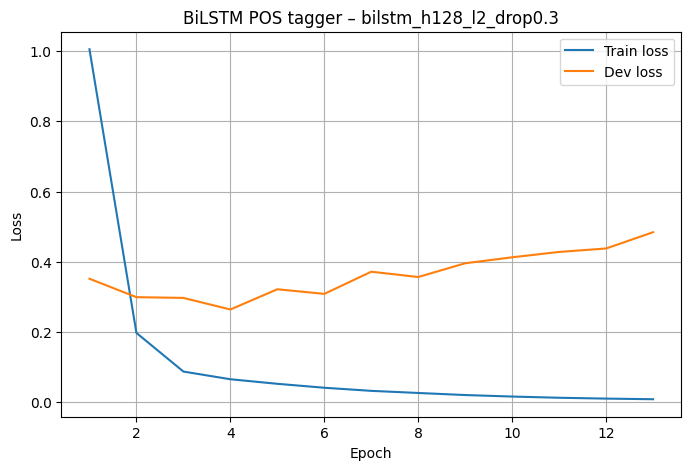

In [17]:
# === LOSS CURVES FOR BEST BiLSTM ===
train_loss_rnn = best_rnn_history["train_loss"]
dev_loss_rnn   = best_rnn_history["dev_loss"]
epochs_rnn = range(1, len(train_loss_rnn) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_rnn, train_loss_rnn, label="Train loss")
plt.plot(epochs_rnn, dev_loss_rnn,   label="Dev loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"BiLSTM POS tagger – {best_rnn_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
def make_results_row_from_preds(model_name, y_true, y_pred, y_proba, idx2tag):
    """
    Build one row with:
      P(tag), R(tag), F1(tag), PR-AUC(tag) for each tag,
      plus Macro-P/R/F1/PR-AUC,
    computed from y_true / y_pred / y_proba.
    """
    num_tags = len(idx2tag)
    label_order = list(range(num_tags))

    prf_dict = per_class_prf(y_true, y_pred, label_order)
    ap_dict  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": model_name}
    per_class_vals = []

    for lbl in label_order:
        tag = idx2tag[lbl]
        P, R, F1 = prf_dict[lbl]
        A = ap_dict[lbl]
        row[f"P({tag})"]      = float(P)
        row[f"R({tag})"]      = float(R)
        row[f"F1({tag})"]     = float(F1)
        row[f"PR-AUC({tag})"] = float(A)
        per_class_vals.append((P, R, F1, A))

    macro_P, macro_R, macro_F1, macro_A = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro_P)
    row["Macro-R"]      = float(macro_R)
    row["Macro-F1"]     = float(macro_F1)
    row["Macro-PR-AUC"] = float(macro_A)
    return row


[ws5_emb100_h256_drop0.3] Epoch 1/20 | train loss: 0.5188 | dev loss: 0.2447 | dev macro-F1: 0.9177
[ws5_emb100_h256_drop0.3] Epoch 2/20 | train loss: 0.1104 | dev loss: 0.2326 | dev macro-F1: 0.9332
[ws5_emb100_h256_drop0.3] Epoch 3/20 | train loss: 0.0566 | dev loss: 0.2457 | dev macro-F1: 0.9308
[ws5_emb100_h256_drop0.3] Epoch 4/20 | train loss: 0.0351 | dev loss: 0.2764 | dev macro-F1: 0.9339
[ws5_emb100_h256_drop0.3] Epoch 5/20 | train loss: 0.0218 | dev loss: 0.2901 | dev macro-F1: 0.9298
[ws5_emb100_h256_drop0.3] Epoch 6/20 | train loss: 0.0156 | dev loss: 0.3065 | dev macro-F1: 0.9290
[ws5_emb100_h256_drop0.3] Epoch 7/20 | train loss: 0.0115 | dev loss: 0.4047 | dev macro-F1: 0.9324
Early stopping (MLP).

=== Best MLP config (from 3b, retrained here) ===
{'name': 'ws5_emb100_h256_drop0.3', 'window_size': 5, 'emb_dim': 100, 'hidden_sizes': [256], 'dropout': 0.3, 'lr': 0.001, 'batch_size': 128, 'num_epochs': 20}
Best Dev Macro-F1 (MLP): 0.9339


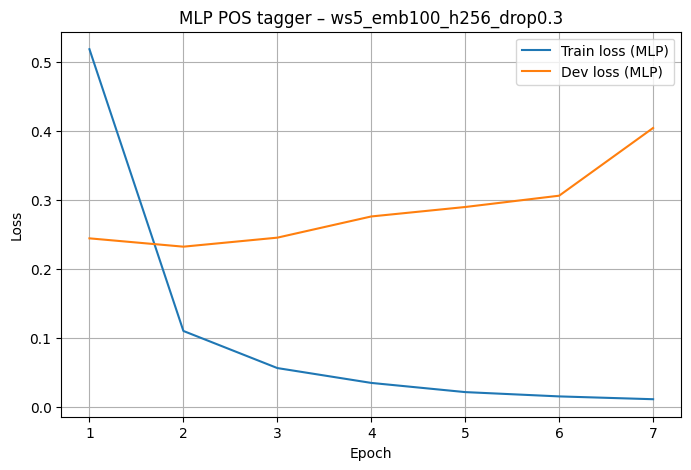


=== MLP POS TAGGER RESULTS (RECOMPUTED) ===

===== TRAIN (MLP) =====
Per-tag metrics:
Tag    ADJ | P=0.9957  R=0.9948  F1=0.9953  PR-AUC=0.9997
Tag    ADP | P=0.9983  R=0.9974  F1=0.9978  PR-AUC=1.0000
Tag    ADV | P=0.9957  R=0.9892  F1=0.9924  PR-AUC=0.9996
Tag    AUX | P=1.0000  R=0.9980  F1=0.9990  PR-AUC=1.0000
Tag  CCONJ | P=0.9915  R=0.9960  F1=0.9937  PR-AUC=0.9997
Tag    DET | P=0.9936  R=0.9882  F1=0.9909  PR-AUC=0.9996
Tag   INTJ | P=0.9958  R=1.0000  F1=0.9979  PR-AUC=0.9999
Tag   NOUN | P=0.9983  R=0.9985  F1=0.9984  PR-AUC=1.0000
Tag    NUM | P=0.9958  R=0.9958  F1=0.9958  PR-AUC=0.9999
Tag   PRON | P=0.9812  R=0.9909  F1=0.9860  PR-AUC=0.9991
Tag  PROPN | P=0.9965  R=0.9970  F1=0.9968  PR-AUC=0.9999
Tag  SCONJ | P=0.9825  R=0.9934  F1=0.9879  PR-AUC=0.9992
Tag   VERB | P=0.9997  R=0.9999  F1=0.9998  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9942
  Macro-R:       0.9953
  Macro-F1:      0.9947
  Macro-PR-AUC:  0.9997

===== DEV   (MLP) =====
Per-tag metrics:
Tag 

,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9957,0.9948,0.9953,0.9997,0.9983,0.9974,0.9978,1.0000,0.9957,...,0.9879,0.9992,0.9997,0.9999,0.9998,1.0000,0.9942,0.9953,0.9947,0.9997
2,BiLSTM,0.9931,0.9880,0.9906,0.9993,0.9912,0.9986,0.9948,0.9998,0.9874,...,0.9699,0.9923,0.9990,0.9992,0.9991,1.0000,0.9880,0.9879,0.9879,0.9984



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9363,0.7257,0.8176,0.8923,0.9902,0.9892,0.9897,0.9988,0.9557,...,0.9109,0.9718,0.8246,0.9948,0.9017,0.9821,0.9509,0.9223,0.9339,0.9735
2,BiLSTM,0.9611,0.7119,0.8180,0.8880,0.9871,0.9935,0.9903,0.9990,0.9678,...,0.9302,0.9718,0.8266,0.9925,0.9020,0.9755,0.9512,0.9244,0.9352,0.9703



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9545,0.7806,0.8588,0.9129,0.9910,0.9898,0.9904,0.9996,0.9579,...,0.9333,0.9843,0.8279,0.9932,0.9030,0.9786,0.9536,0.9318,0.9409,0.9753
2,BiLSTM,0.9729,0.7646,0.8563,0.9010,0.9877,0.9966,0.9921,0.9992,0.9733,...,0.9483,0.9840,0.8304,0.9916,0.9039,0.9708,0.9501,0.9309,0.9385,0.9720


In [19]:
# ============================================================
# MLP BASELINE FROM ASSIGNMENT 3b
# ------------------------------------------------------------
# Uses:
#   - train_sents, dev_sents, test_sents
#   - word2idx, tag2idx, idx2tag
#   - embedding_weights (Word2Vec)
#   - per_class_prf, per_class_prauc, make_results_row_from_preds
#   - device
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ---------- 1. Windowed dataset for MLP (same as in 3b) ----------

def sentence_to_indices(words, word2idx):
    return [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]

def tags_to_indices(tags, tag2idx):
    return [tag2idx[t] for t in tags]

def make_windows(word_indices, tag_indices, window_size=5, pad_id=None):
    assert len(word_indices) == len(tag_indices)
    if pad_id is None:
        pad_id = word2idx[PAD_TOKEN]
    k = window_size // 2
    padded = [pad_id] * k + word_indices + [pad_id] * k

    X, y = [], []
    for i in range(len(word_indices)):
        window = padded[i : i + window_size]
        X.append(window)
        y.append(tag_indices[i])
    return X, y

def dataset_to_windows(sentences, word2idx, tag2idx, window_size=5):
    all_X, all_y = [], []
    for words, tags in sentences:
        w_idx = sentence_to_indices(words, word2idx)
        t_idx = tags_to_indices(tags, tag2idx)
        X, y = make_windows(w_idx, t_idx, window_size=window_size, pad_id=word2idx[PAD_TOKEN])
        all_X.extend(X)
        all_y.extend(y)
    return all_X, all_y

class WindowPOSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ---------- 2. MLP model (exactly as in 3b) ----------

class MLP_POS(nn.Module):
    def __init__(self, vocab_size, num_tags, window_size, config, embedding_weights=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_tags = num_tags
        self.window_size = window_size

        emb_dim = config["emb_dim"]
        hidden_sizes = config["hidden_sizes"]
        dropout_p = config["dropout"]

        # Embedding layer (initialized with Word2Vec)
        if embedding_weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                embedding_weights, freeze=False  # fine-tune embeddings
            )
        else:
            self.embedding = nn.Embedding(vocab_size, emb_dim)

        layers = []
        input_dim = emb_dim * window_size

        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            input_dim = h

        layers.append(nn.Linear(input_dim, num_tags))  # final layer
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: [batch_size, window_size]
        emb = self.embedding(x)           # [B, W, emb_dim]
        emb = emb.view(emb.size(0), -1)   # [B, W*emb_dim]
        logits = self.mlp(emb)            # [B, num_tags]
        return logits


# ---------- 3. Helpers for training & evaluation ----------

from sklearn.metrics import precision_recall_fscore_support, average_precision_score
import numpy as np

def predict_loader(model, loader, device):
    model.eval()
    all_y_true, all_y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_y_pred.append(preds)
            all_y_true.append(yb.cpu().numpy())
    return np.concatenate(all_y_true), np.concatenate(all_y_pred)

def predict_proba_loader(model, loader, device):
    model.eval()
    all_y_true, all_y_pred, all_y_proba = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_y_true.append(yb.numpy())
            all_y_pred.append(preds)
            all_y_proba.append(probs)

    return (
        np.concatenate(all_y_true),
        np.concatenate(all_y_pred),
        np.concatenate(all_y_proba),
    )

def compute_macro_f1_mlp(model, loader, device):
    y_true, y_pred = predict_loader(model, loader, device)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return macro_f1

def train_one_mlp_config(config, train_dataset, dev_dataset, vocab_size, num_tags, device, embedding_weights):
    """
    Train a single MLP_POS with given config and return:
      model with best dev macro-F1,
      history dict with train/dev loss,
      best_dev_macro_f1
    """
    batch_size = config["batch_size"]
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_dataset,   batch_size=batch_size, shuffle=False)

    model = MLP_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        window_size=config["window_size"],
        config=config,
        embedding_weights=embedding_weights,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None
    patience = 5

    for epoch in range(config["num_epochs"]):
        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        total_train = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * xb.size(0)
            total_train += xb.size(0)

        epoch_train_loss = running_train_loss / total_train
        history["train_loss"].append(epoch_train_loss)

        # ---- DEV LOSS ----
        model.eval()
        running_dev_loss = 0.0
        total_dev = 0
        with torch.no_grad():
            for xb, yb in dev_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_dev_loss += loss.item() * xb.size(0)
                total_dev += xb.size(0)
        epoch_dev_loss = running_dev_loss / total_dev
        history["dev_loss"].append(epoch_dev_loss)

        # ---- DEV MACRO-F1 ----
        dev_macro_f1 = compute_macro_f1_mlp(model, dev_loader, device)

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # simple early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping (MLP).")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    return model, history, best_dev_macro_f1


# ---------- 4. Build window datasets & train MLP with tuned config ----------

vocab_size = len(word2idx)
num_tags   = len(tag2idx)

mlp_best_config = {
    "name": "ws5_emb100_h256_drop0.3",
    "window_size": 5,
    "emb_dim": 100,
    "hidden_sizes": [256],
    "dropout": 0.3,
    "lr": 1e-3,
    "batch_size": 128,
    "num_epochs": 20,
}

# Windowed data (reuse same word2idx/tag2idx as RNN & baseline)
x_train_m, y_train_m = dataset_to_windows(train_sents, word2idx, tag2idx, mlp_best_config["window_size"])
x_dev_m,   y_dev_m   = dataset_to_windows(dev_sents,   word2idx, tag2idx, mlp_best_config["window_size"])
x_test_m,  y_test_m  = dataset_to_windows(test_sents,  word2idx, tag2idx, mlp_best_config["window_size"])

train_dataset_mlp = WindowPOSDataset(x_train_m, y_train_m)
dev_dataset_mlp   = WindowPOSDataset(x_dev_m,   y_dev_m)
test_dataset_mlp  = WindowPOSDataset(x_test_m,  y_test_m)

mlp_model, mlp_history, mlp_best_dev_macro_f1 = train_one_mlp_config(
    mlp_best_config,
    train_dataset=train_dataset_mlp,
    dev_dataset=dev_dataset_mlp,
    vocab_size=vocab_size,
    num_tags=num_tags,
    device=device,
    embedding_weights=embedding_weights,
)

print("\n=== Best MLP config (from 3b, retrained here) ===")
print(mlp_best_config)
print(f"Best Dev Macro-F1 (MLP): {mlp_best_dev_macro_f1:.4f}")

# Plot MLP loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mlp_history["train_loss"]) + 1), mlp_history["train_loss"], label="Train loss (MLP)")
plt.plot(range(1, len(mlp_history["dev_loss"]) + 1),   mlp_history["dev_loss"],   label="Dev loss (MLP)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"MLP POS tagger – {mlp_best_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


# ---------- 5. Get MLP predictions & probabilities on TRAIN / DEV / TEST ----------

batch_size_mlp_eval = 128
train_loader_mlp = DataLoader(train_dataset_mlp, batch_size=batch_size_mlp_eval, shuffle=False)
dev_loader_mlp   = DataLoader(dev_dataset_mlp,   batch_size=batch_size_mlp_eval, shuffle=False)
test_loader_mlp  = DataLoader(test_dataset_mlp,  batch_size=batch_size_mlp_eval, shuffle=False)

y_train_true_m, y_train_pred_m, y_train_proba_m = predict_proba_loader(mlp_model, train_loader_mlp, device)
y_dev_true_m,   y_dev_pred_m,   y_dev_proba_m   = predict_proba_loader(mlp_model, dev_loader_mlp,   device)
y_test_true_m,  y_test_pred_m,  y_test_proba_m  = predict_proba_loader(mlp_model, test_loader_mlp,  device)

print("\n=== MLP POS TAGGER RESULTS (RECOMPUTED) ===")
evaluate_split_full("TRAIN (MLP)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag)
evaluate_split_full("DEV   (MLP)", y_dev_true_m,   y_dev_pred_m,   y_dev_proba_m,   idx2tag)
evaluate_split_full("TEST  (MLP)", y_test_true_m,  y_test_pred_m,  y_test_proba_m,  idx2tag)


# ============================================================
# 6. FINAL COMPARISON TABLES: Baseline vs MLP vs BiLSTM
# ============================================================

baseline_train_row = make_results_row_from_preds(
    "Baseline", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag
)
bilstm_train_row = make_results_row_from_preds(
    "BiLSTM",  y_train_true_r, y_train_pred_r, y_train_proba_r, idx2tag
)
mlp_train_row = make_results_row_from_preds(
    "MLP (best config)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag
)

baseline_dev_row = make_results_row_from_preds(
    "Baseline", y_dev_true_b, y_dev_pred_b, y_dev_proba_b, idx2tag
)
bilstm_dev_row = make_results_row_from_preds(
    "BiLSTM",  y_dev_true_r, y_dev_pred_r, y_dev_proba_r, idx2tag
)
mlp_dev_row = make_results_row_from_preds(
    "MLP (best config)", y_dev_true_m, y_dev_pred_m, y_dev_proba_m, idx2tag
)

baseline_test_row = make_results_row_from_preds(
    "Baseline", y_test_true_b, y_test_pred_b, y_test_proba_b, idx2tag
)
bilstm_test_row = make_results_row_from_preds(
    "BiLSTM",  y_test_true_r, y_test_pred_r, y_test_proba_r, idx2tag
)
mlp_test_row = make_results_row_from_preds(
    "MLP (best config)", y_test_true_m, y_test_pred_m, y_test_proba_m, idx2tag
)

# Column order
tags = [idx2tag[i] for i in range(len(idx2tag))]
cols = ["Model"]
for t in tags:
    cols += [f"P({t})", f"R({t})", f"F1({t})", f"PR-AUC({t})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

# Build DataFrames
train_rows = [baseline_train_row, mlp_train_row, bilstm_train_row]
dev_rows   = [baseline_dev_row,   mlp_dev_row,   bilstm_dev_row]
test_rows  = [baseline_test_row,  mlp_test_row,  bilstm_test_row]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


In [20]:
from collections import Counter

CHAR_PAD = "<CPAD>"
CHAR_UNK = "<CUNK>"

def build_char_vocab(sentences):
    """
    Build a character vocabulary from the training sentences.
    """
    counter = Counter()
    for words, _ in sentences:
        for w in words:
            counter.update(list(w))

    char2idx = {CHAR_PAD: 0, CHAR_UNK: 1}
    idx2char = [CHAR_PAD, CHAR_UNK]

    for ch, _ in counter.most_common():
        if ch not in char2idx:
            char2idx[ch] = len(idx2char)
            idx2char.append(ch)

    return char2idx, idx2char

char2idx, idx2char = build_char_vocab(train_sents)
char_pad_idx = char2idx[CHAR_PAD]

print("Char vocab size:", len(char2idx))


Char vocab size: 177


In [21]:
class SentencePOSDatasetWithChars(Dataset):
    """
    Each item:
      - word_ids: LongTensor [seq_len]
      - tag_ids:  LongTensor [seq_len]
      - char_ids: list of LongTensors, each [word_len]
    """
    def __init__(self, sentences, word2idx, tag2idx, char2idx):
        self.sent_word_ids = []
        self.sent_tag_ids = []
        self.sent_char_ids = []

        for words, tags in sentences:
            w_ids = [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]
            t_ids = [tag2idx[t] for t in tags]

            char_seqs = []
            for w in words:
                ch_ids = [char2idx.get(ch, char2idx[CHAR_UNK]) for ch in w]
                char_seqs.append(torch.tensor(ch_ids, dtype=torch.long))

            assert len(w_ids) == len(t_ids) == len(char_seqs)
            self.sent_word_ids.append(torch.tensor(w_ids, dtype=torch.long))
            self.sent_tag_ids.append(torch.tensor(t_ids, dtype=torch.long))
            self.sent_char_ids.append(char_seqs)

    def __len__(self):
        return len(self.sent_word_ids)

    def __getitem__(self, idx):
        return self.sent_word_ids[idx], self.sent_tag_ids[idx], self.sent_char_ids[idx]


In [22]:
train_seq_dataset_chars = SentencePOSDatasetWithChars(train_sents, word2idx, tag2idx, char2idx)
dev_seq_dataset_chars   = SentencePOSDatasetWithChars(dev_sents,   word2idx, tag2idx, char2idx)
test_seq_dataset_chars  = SentencePOSDatasetWithChars(test_sents,  word2idx, tag2idx, char2idx)

print("Char-aware datasets:",
      len(train_seq_dataset_chars),
      len(dev_seq_dataset_chars),
      len(test_seq_dataset_chars))


Char-aware datasets: 15016 1019 1047


In [23]:
def collate_sentences_with_chars(batch):
    """
    batch: list of (word_ids, tag_ids, char_ids_list)
      word_ids: LongTensor [L]
      tag_ids:  LongTensor [L]
      char_ids_list: list of LongTensors [len(word_i)]

    Returns:
      X_words:  [B, T]
      X_chars:  [B, T, W]   (char ids, padded)
      y:        [B, T]      (with IGNORED_TAG_INDEX in padded positions)
      lengths:  [B]
    """
    word_seqs, tag_seqs, char_seqs_list = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in word_seqs], dtype=torch.long)
    max_len = lengths.max().item()
    batch_size = len(word_seqs)

    # word + tag padding
    X_words = torch.full((batch_size, max_len), pad_idx, dtype=torch.long)
    y       = torch.full((batch_size, max_len), IGNORED_TAG_INDEX, dtype=torch.long)

    # max word length in this batch
    max_word_len = 1
    for sent_chars in char_seqs_list:
        for ch_seq in sent_chars:
            if len(ch_seq) > max_word_len:
                max_word_len = len(ch_seq)

    X_chars = torch.full(
        (batch_size, max_len, max_word_len),
        char_pad_idx,
        dtype=torch.long
    )

    # fill
    for i, (w_seq, t_seq, sent_chars) in enumerate(zip(word_seqs, tag_seqs, char_seqs_list)):
        L = len(w_seq)
        X_words[i, :L] = w_seq
        y[i, :L]       = t_seq

        for j, ch_seq in enumerate(sent_chars):
            cl = len(ch_seq)
            X_chars[i, j, :cl] = ch_seq

    return X_words, X_chars, y, lengths


In [24]:
class CharAwareBiLSTM_POS(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_tags,
        config,
        embedding_weights=None,
        pad_idx=0,
        char_vocab_size=None,
        char_pad_idx=0,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.use_char_rnn = config.get("use_char_rnn", True)

        emb_dim        = config["emb_dim"]
        hidden_dim     = config["hidden_dim"]
        num_layers     = config["num_layers"]
        rnn_dropout    = config["rnn_dropout"]
        fc_dropout     = config["fc_dropout"]
        char_emb_dim   = config.get("char_emb_dim", 50)
        char_hidden_dim= config.get("char_hidden_dim", 50)

        # ----- Word embedding -----
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )
        if embedding_weights is not None:
            self.embedding.weight.data.copy_(embedding_weights)

        # ----- Char-level BiLSTM -----
        if self.use_char_rnn:
            assert char_vocab_size is not None, "char_vocab_size must be provided"
            self.char_embedding = nn.Embedding(
                num_embeddings=char_vocab_size,
                embedding_dim=char_emb_dim,
                padding_idx=char_pad_idx,
            )
            self.char_lstm = nn.LSTM(
                input_size=char_emb_dim,
                hidden_size=char_hidden_dim,
                num_layers=1,
                batch_first=True,
                bidirectional=True,
            )
            rnn_input_dim = emb_dim + 2 * char_hidden_dim
        else:
            rnn_input_dim = emb_dim

        # ----- Word-level BiLSTM -----
        self.lstm = nn.LSTM(
            input_size=rnn_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
        )

        # ----- Final classifier -----
        self.dropout = nn.Dropout(fc_dropout)
        self.fc = nn.Linear(2 * hidden_dim, num_tags)

    def forward(self, x_words, lengths, x_chars=None):
        """
        x_words: [B, T]
        x_chars: [B, T, W] or None
        lengths: [B]
        """
        B, T = x_words.size()
        word_emb = self.embedding(x_words)  # [B, T, emb_dim]

        if self.use_char_rnn and x_chars is not None:
            B, T, W = x_chars.size()
            # char_emb: [B*T, W, char_emb_dim]
            char_emb = self.char_embedding(x_chars.view(B * T, W))
            # run char BiLSTM
            _, (h_n, _) = self.char_lstm(char_emb)  # h_n: [2, B*T, char_hidden_dim]
            # concatenate final forward/backward hidden states
            char_rep = torch.cat([h_n[-2], h_n[-1]], dim=-1)  # [B*T, 2*char_hidden_dim]
            char_rep = char_rep.view(B, T, -1)
            # concat word + char reps
            word_rep = torch.cat([word_emb, char_rep], dim=-1)
        else:
            word_rep = word_emb

        # word-level BiLSTM over sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            word_rep, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        out = self.dropout(out)
        logits = self.fc(out)  # [B, T, num_tags]
        return logits


In [25]:
def train_one_char_rnn_config(
    config,
    train_dataset,
    dev_dataset,
    vocab_size,
    char_vocab_size,
    num_tags,
    device,
    patience=5,
):
    batch_size = config["batch_size"]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_sentences_with_chars,
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_sentences_with_chars,
    )

    model = CharAwareBiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
        char_pad_idx=char_pad_idx,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state = None

    for epoch in range(config["num_epochs"]):
        # ----- TRAIN -----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xw, Xc, yb, lengths in train_loader:
            Xw, Xc, yb, lengths = Xw.to(device), Xc.to(device), yb.to(device), lengths.to(device)
            optimizer.zero_grad()

            logits = model(Xw, lengths, Xc)         # [B, T, C]
            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ----- DEV LOSS -----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for Xw, Xc, yb, lengths in dev_loader:
                Xw, Xc, yb, lengths = Xw.to(device), Xc.to(device), yb.to(device), lengths.to(device)
                logits = model(Xw, lengths, Xc)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ----- DEV MACRO-F1 -----
        y_true_dev, y_pred_dev, _ = predict_seq_with_proba_char(
            model, dev_loader, device
        )
        _, _, macro_f1, _ = precision_recall_fscore_support(
            y_true_dev, y_pred_dev, average="macro", zero_division=0
        )

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {macro_f1:.4f}"
        )

        if macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, history, best_dev_macro_f1


In [26]:
def predict_seq_with_proba_char(model, loader, device):
    model.eval()
    all_true, all_pred, all_proba = [], [], []

    with torch.no_grad():
        for Xw, Xc, yb, lengths in loader:
            Xw, Xc, yb, lengths = Xw.to(device), Xc.to(device), yb.to(device), lengths.to(device)
            logits = model(Xw, lengths, Xc)
            proba = F.softmax(logits, dim=-1)

            B, T, C = proba.shape
            proba_flat = proba.view(-1, C)
            y_flat = yb.view(-1)

            mask = (y_flat != IGNORED_TAG_INDEX)
            y_true = y_flat[mask].cpu().numpy()
            y_proba = proba_flat[mask].cpu().numpy()
            y_pred = np.argmax(y_proba, axis=1)

            all_true.append(y_true)
            all_pred.append(y_pred)
            all_proba.append(y_proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.vstack(all_proba)
    return y_true, y_pred, y_proba


In [27]:
def train_one_rnn_with_temporal_averaging(
    config,
    train_dataset,
    dev_dataset,
    vocab_size,
    num_tags,
    device,
    patience=5,
):
    """
    Independent trainer that:
      - trains a BiLSTM_POS with the given config
      - keeps both:
          best checkpoint by dev macro-F1
          temporal average of weights over epochs
    Returns:
      best_model, avg_model, history, best_dev_macro_f1, avg_dev_macro_f1
    """
    batch_size = config["batch_size"]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_sentences,
    )
    dev_loader = DataLoader(
        dev_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_sentences,
    )

    model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}

    best_dev_macro_f1 = -1.0
    best_state_dict = None

    # for temporal averaging
    avg_state_dict = None
    avg_count = 0

    for epoch in range(config["num_epochs"]):
        # ----- TRAIN -----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xb, yb, lengths in train_loader:
            Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
            optimizer.zero_grad()

            logits = model(Xb, lengths)          # [B, T, C]
            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ----- DEV LOSS -----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for Xb, yb, lengths in dev_loader:
                Xb, yb, lengths = Xb.to(device), yb.to(device), lengths.to(device)
                logits = model(Xb, lengths)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ----- DEV MACRO-F1 -----
        dev_macro_f1 = compute_macro_f1_seq(model, dev_loader, device)

        print(
            f"[{config['name']} (TA)] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        # Update best checkpoint
        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Update temporal average of weights
        with torch.no_grad():
            current_state = model.state_dict()
            if avg_state_dict is None:
                avg_state_dict = {k: v.cpu().clone() for k, v in current_state.items()}
                avg_count = 1
            else:
                avg_count += 1
                for k, v in current_state.items():
                    avg_state_dict[k].mul_((avg_count - 1) / avg_count).add_(v.cpu() / avg_count)

        # Early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience + 1):]
            worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping triggered (temporal-avg trainer).")
                break

    # ----- Build best-model and avg-model -----
    # best checkpoint
    best_model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)
    if best_state_dict is not None:
        best_model.load_state_dict(best_state_dict)

    # temporal-averaged model
    avg_model = BiLSTM_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
    ).to(device)
    if avg_state_dict is not None:
        avg_model.load_state_dict(avg_state_dict)

    # compute dev macro-F1 of averaged model
    dev_macro_f1_avg = compute_macro_f1_seq(avg_model, dev_loader, device)

    print(f"\n[{config['name']} (TA)] Best dev macro-F1 (single ckpt): {best_dev_macro_f1:.4f}")
    print(f"[{config['name']} (TA)] Dev macro-F1 (temporal avg):      {dev_macro_f1_avg:.4f}")

    return best_model, avg_model, history, best_dev_macro_f1, dev_macro_f1_avg


In [28]:
char_rnn_config = {
    "name": "bilstm_char+word_h128_l2",
    "emb_dim": embedding_weights.shape[1],
    "hidden_dim": 128,
    "num_layers": 2,
    "rnn_dropout": 0.3,
    "fc_dropout": 0.5,
    "char_emb_dim": 50,
    "char_hidden_dim": 50,
    "use_char_rnn": True,
    "lr": 1e-3,
    "batch_size": 64,
    "num_epochs": 20,
}

best_char_model, char_history, char_dev_macro_f1 = train_one_char_rnn_config(
    char_rnn_config,
    train_seq_dataset_chars,
    dev_seq_dataset_chars,
    vocab_size=vocab_size,
    char_vocab_size=len(char2idx),
    num_tags=num_tags,
    device=device,
    patience=5,
)

print("Best char-aware dev macro-F1:", char_dev_macro_f1)


[bilstm_char+word_h128_l2] Epoch 1/20 | train loss: 0.8869 | dev loss: 0.2607 | dev macro-F1: 0.8897
[bilstm_char+word_h128_l2] Epoch 2/20 | train loss: 0.1701 | dev loss: 0.1690 | dev macro-F1: 0.9424
[bilstm_char+word_h128_l2] Epoch 3/20 | train loss: 0.0901 | dev loss: 0.1610 | dev macro-F1: 0.9468
[bilstm_char+word_h128_l2] Epoch 4/20 | train loss: 0.0671 | dev loss: 0.1831 | dev macro-F1: 0.9452
[bilstm_char+word_h128_l2] Epoch 5/20 | train loss: 0.0534 | dev loss: 0.1642 | dev macro-F1: 0.9506
[bilstm_char+word_h128_l2] Epoch 6/20 | train loss: 0.0433 | dev loss: 0.1886 | dev macro-F1: 0.9486
[bilstm_char+word_h128_l2] Epoch 7/20 | train loss: 0.0342 | dev loss: 0.1755 | dev macro-F1: 0.9503
[bilstm_char+word_h128_l2] Epoch 8/20 | train loss: 0.0261 | dev loss: 0.2090 | dev macro-F1: 0.9425
[bilstm_char+word_h128_l2] Epoch 9/20 | train loss: 0.0202 | dev loss: 0.1922 | dev macro-F1: 0.9484
[bilstm_char+word_h128_l2] Epoch 10/20 | train loss: 0.0159 | dev loss: 0.2286 | dev macro-

In [29]:
# === EVALUATE CHAR-AWARE BiLSTM ON TRAIN / DEV / TEST ===

eval_batch_size = 64
train_seq_loader_chars = DataLoader(
    train_seq_dataset_chars,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences_with_chars,
)
dev_seq_loader_chars = DataLoader(
    dev_seq_dataset_chars,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences_with_chars,
)
test_seq_loader_chars = DataLoader(
    test_seq_dataset_chars,
    batch_size=eval_batch_size,
    shuffle=False,
    collate_fn=collate_sentences_with_chars,
)

y_train_true_c, y_train_pred_c, y_train_proba_c = predict_seq_with_proba_char(
    best_char_model, train_seq_loader_chars, device
)
y_dev_true_c, y_dev_pred_c, y_dev_proba_c = predict_seq_with_proba_char(
    best_char_model, dev_seq_loader_chars, device
)
y_test_true_c, y_test_pred_c, y_test_proba_c = predict_seq_with_proba_char(
    best_char_model, test_seq_loader_chars, device
)

print("\n\n=== Char+Word BiLSTM POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (BiLSTM-char)", y_train_true_c, y_train_pred_c, y_train_proba_c, idx2tag)
evaluate_split_full("DEV   (BiLSTM-char)", y_dev_true_c,   y_dev_pred_c,   y_dev_proba_c,   idx2tag)
evaluate_split_full("TEST  (BiLSTM-char)", y_test_true_c,  y_test_pred_c,  y_test_proba_c,  idx2tag)




=== Char+Word BiLSTM POS TAGGER RESULTS ===

===== TRAIN (BiLSTM-char) =====
Per-tag metrics:
Tag    ADJ | P=0.9935  R=0.9865  F1=0.9900  PR-AUC=0.9994
Tag    ADP | P=0.9944  R=0.9979  F1=0.9961  PR-AUC=0.9998
Tag    ADV | P=0.9908  R=0.9674  F1=0.9790  PR-AUC=0.9976
Tag    AUX | P=0.9983  R=0.9983  F1=0.9983  PR-AUC=0.9999
Tag  CCONJ | P=0.9678  R=0.9929  F1=0.9802  PR-AUC=0.9974
Tag    DET | P=0.9779  R=0.9863  F1=0.9821  PR-AUC=0.9986
Tag   INTJ | P=0.9936  R=0.9852  F1=0.9894  PR-AUC=0.9996
Tag   NOUN | P=0.9966  R=0.9982  F1=0.9974  PR-AUC=0.9999
Tag    NUM | P=0.9972  R=0.9874  F1=0.9922  PR-AUC=0.9992
Tag   PRON | P=0.9747  R=0.9697  F1=0.9722  PR-AUC=0.9968
Tag  PROPN | P=0.9959  R=0.9950  F1=0.9954  PR-AUC=0.9997
Tag  SCONJ | P=0.9637  R=0.9792  F1=0.9714  PR-AUC=0.9937
Tag   VERB | P=0.9997  R=0.9987  F1=0.9992  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9880
  Macro-R:       0.9879
  Macro-F1:      0.9879
  Macro-PR-AUC:  0.9986

===== DEV   (BiLSTM-char) =====
Per-

{'Macro-P': np.float64(0.9512261259857699),
 'Macro-R': np.float64(0.9574766060642399),
 'Macro-F1': np.float64(0.953418968329857),
 'Macro-PR-AUC': np.float64(0.9870429747310664)}

In [30]:
baseline_train_row = make_results_row_from_preds(
    "Baseline", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag
)
mlp_train_row = make_results_row_from_preds(
    "MLP (best config)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag
)
bilstm_train_row = make_results_row_from_preds(
    "BiLSTM",  y_train_true_r, y_train_pred_r, y_train_proba_r, idx2tag
)

baseline_dev_row = make_results_row_from_preds(
    "Baseline", y_dev_true_b, y_dev_pred_b, y_dev_proba_b, idx2tag
)
mlp_dev_row = make_results_row_from_preds(
    "MLP (best config)", y_dev_true_m, y_dev_pred_m, y_dev_proba_m, idx2tag
)
bilstm_dev_row = make_results_row_from_preds(
    "BiLSTM",  y_dev_true_r, y_dev_pred_r, y_dev_proba_r, idx2tag
)

baseline_test_row = make_results_row_from_preds(
    "Baseline", y_test_true_b, y_test_pred_b, y_test_proba_b, idx2tag
)
mlp_test_row = make_results_row_from_preds(
    "MLP (best config)", y_test_true_m, y_test_pred_m, y_test_proba_m, idx2tag
)
bilstm_test_row = make_results_row_from_preds(
    "BiLSTM",  y_test_true_r, y_test_pred_r, y_test_proba_r, idx2tag
)

bilstm_char_train_row = make_results_row_from_preds(
    "BiLSTM-char", y_train_true_c, y_train_pred_c, y_train_proba_c, idx2tag
)
bilstm_char_dev_row = make_results_row_from_preds(
    "BiLSTM-char", y_dev_true_c, y_dev_pred_c, y_dev_proba_c, idx2tag
)
bilstm_char_test_row = make_results_row_from_preds(
    "BiLSTM-char", y_test_true_c, y_test_pred_c, y_test_proba_c, idx2tag
)

# Column order
tags = [idx2tag[i] for i in range(len(idx2tag))]
cols = ["Model"]
for t in tags:
    cols += [f"P({t})", f"R({t})", f"F1({t})", f"PR-AUC({t})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

# Build DataFrames
train_rows = [baseline_train_row, mlp_train_row, bilstm_train_row, bilstm_char_train_row]
dev_rows   = [baseline_dev_row,   mlp_dev_row,   bilstm_dev_row,   bilstm_char_dev_row]
test_rows  = [baseline_test_row,  mlp_test_row,  bilstm_test_row,  bilstm_char_test_row]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9957,0.9948,0.9953,0.9997,0.9983,0.9974,0.9978,1.0000,0.9957,...,0.9879,0.9992,0.9997,0.9999,0.9998,1.0000,0.9942,0.9953,0.9947,0.9997
2,BiLSTM,0.9931,0.9880,0.9906,0.9993,0.9912,0.9986,0.9948,0.9998,0.9874,...,0.9699,0.9923,0.9990,0.9992,0.9991,1.0000,0.9880,0.9879,0.9879,0.9984
3,BiLSTM-char,0.9935,0.9865,0.9900,0.9994,0.9944,0.9979,0.9961,0.9998,0.9908,...,0.9714,0.9937,0.9997,0.9987,0.9992,1.0000,0.9880,0.9879,0.9879,0.9986



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9363,0.7257,0.8176,0.8923,0.9902,0.9892,0.9897,0.9988,0.9557,...,0.9109,0.9718,0.8246,0.9948,0.9017,0.9821,0.9509,0.9223,0.9339,0.9735
2,BiLSTM,0.9611,0.7119,0.8180,0.8880,0.9871,0.9935,0.9903,0.9990,0.9678,...,0.9302,0.9718,0.8266,0.9925,0.9020,0.9755,0.9512,0.9244,0.9352,0.9703
3,BiLSTM-char,0.7468,0.8903,0.8123,0.9260,0.9913,0.9935,0.9924,0.9997,0.9774,...,0.9326,0.9769,0.9556,0.9921,0.9735,0.9968,0.9487,0.9542,0.9506,0.9859



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9545,0.7806,0.8588,0.9129,0.9910,0.9898,0.9904,0.9996,0.9579,...,0.9333,0.9843,0.8279,0.9932,0.9030,0.9786,0.9536,0.9318,0.9409,0.9753
2,BiLSTM,0.9729,0.7646,0.8563,0.9010,0.9877,0.9966,0.9921,0.9992,0.9733,...,0.9483,0.9840,0.8304,0.9916,0.9039,0.9708,0.9501,0.9309,0.9385,0.9720
3,BiLSTM-char,0.7456,0.9082,0.8189,0.9443,0.9932,0.9966,0.9949,0.9998,0.9771,...,0.9433,0.9854,0.9531,0.9868,0.9697,0.9959,0.9512,0.9575,0.9534,0.9870


In [31]:
# ============================================================
# BiLSTM with temporal averaging (using best_rnn_config)
# ============================================================

best_ta_model, avg_ta_model, ta_history, best_ta_dev_macro_f1, ta_dev_macro_f1_avg = \
    train_one_rnn_with_temporal_averaging(
        best_rnn_config,
        train_seq_dataset,
        dev_seq_dataset,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        patience=5,
    )

print("\n=== Temporal averaging run ===")
print("Best single-ckpt dev macro-F1 (TA run):", best_ta_dev_macro_f1)
print("Temporal-avg   dev macro-F1 (avg_model):", ta_dev_macro_f1_avg)


[bilstm_h128_l2_drop0.3 (TA)] Epoch 1/20 | train loss: 1.0055 | dev loss: 0.3418 | dev macro-F1: 0.8592
[bilstm_h128_l2_drop0.3 (TA)] Epoch 2/20 | train loss: 0.1905 | dev loss: 0.2493 | dev macro-F1: 0.9255
[bilstm_h128_l2_drop0.3 (TA)] Epoch 3/20 | train loss: 0.0880 | dev loss: 0.2789 | dev macro-F1: 0.9311
[bilstm_h128_l2_drop0.3 (TA)] Epoch 4/20 | train loss: 0.0671 | dev loss: 0.2767 | dev macro-F1: 0.9355
[bilstm_h128_l2_drop0.3 (TA)] Epoch 5/20 | train loss: 0.0534 | dev loss: 0.3013 | dev macro-F1: 0.9340
[bilstm_h128_l2_drop0.3 (TA)] Epoch 6/20 | train loss: 0.0421 | dev loss: 0.3314 | dev macro-F1: 0.9338
[bilstm_h128_l2_drop0.3 (TA)] Epoch 7/20 | train loss: 0.0331 | dev loss: 0.3529 | dev macro-F1: 0.9354
[bilstm_h128_l2_drop0.3 (TA)] Epoch 8/20 | train loss: 0.0266 | dev loss: 0.3629 | dev macro-F1: 0.9344
[bilstm_h128_l2_drop0.3 (TA)] Epoch 9/20 | train loss: 0.0217 | dev loss: 0.3750 | dev macro-F1: 0.9333
Early stopping triggered (temporal-avg trainer).

[bilstm_h128_l

In [32]:
# ============================================================
# EVALUATION OF TEMPORAL-AVERAGED BiLSTM ON TRAIN / DEV / TEST
# ============================================================

y_train_true_ta, y_train_pred_ta, y_train_proba_ta = predict_seq_with_proba(
    avg_ta_model, train_seq_loader, device
)
y_dev_true_ta,   y_dev_pred_ta,   y_dev_proba_ta   = predict_seq_with_proba(
    avg_ta_model, dev_seq_loader, device
)
y_test_true_ta,  y_test_pred_ta,  y_test_proba_ta  = predict_seq_with_proba(
    avg_ta_model, test_seq_loader, device
)

print("\n\n=== BiLSTM (Temporal Averaging) POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (BiLSTM-TA)", y_train_true_ta, y_train_pred_ta, y_train_proba_ta, idx2tag)
evaluate_split_full("DEV   (BiLSTM-TA)", y_dev_true_ta,   y_dev_pred_ta,   y_dev_proba_ta,   idx2tag)
evaluate_split_full("TEST  (BiLSTM-TA)", y_test_true_ta,  y_test_pred_ta,  y_test_proba_ta,  idx2tag)




=== BiLSTM (Temporal Averaging) POS TAGGER RESULTS ===

===== TRAIN (BiLSTM-TA) =====
Per-tag metrics:
Tag    ADJ | P=0.9899  R=0.9927  F1=0.9913  PR-AUC=0.9995
Tag    ADP | P=0.9929  R=0.9972  F1=0.9950  PR-AUC=0.9998
Tag    ADV | P=0.9894  R=0.9685  F1=0.9788  PR-AUC=0.9979
Tag    AUX | P=0.9991  R=0.9968  F1=0.9980  PR-AUC=0.9996
Tag  CCONJ | P=0.9692  R=0.9938  F1=0.9813  PR-AUC=0.9982
Tag    DET | P=0.9728  R=0.9878  F1=0.9802  PR-AUC=0.9984
Tag   INTJ | P=0.9957  R=0.9831  F1=0.9894  PR-AUC=0.9995
Tag   NOUN | P=0.9979  R=0.9986  F1=0.9983  PR-AUC=1.0000
Tag    NUM | P=0.9986  R=0.9824  F1=0.9904  PR-AUC=0.9984
Tag   PRON | P=0.9793  R=0.9598  F1=0.9695  PR-AUC=0.9963
Tag  PROPN | P=0.9960  R=0.9973  F1=0.9966  PR-AUC=0.9997
Tag  SCONJ | P=0.9662  R=0.9662  F1=0.9662  PR-AUC=0.9925
Tag   VERB | P=0.9997  R=0.9997  F1=0.9997  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9882
  Macro-R:       0.9864
  Macro-F1:      0.9873
  Macro-PR-AUC:  0.9984

===== DEV   (BiLSTM-TA) ===

{'Macro-P': np.float64(0.9585702168172705),
 'Macro-R': np.float64(0.9286991183624166),
 'Macro-F1': np.float64(0.9413166231276591),
 'Macro-PR-AUC': np.float64(0.974154844344024)}

In [33]:
bilstm_ta_train_row = make_results_row_from_preds(
    "BiLSTM-TA", y_train_true_ta, y_train_pred_ta, y_train_proba_ta, idx2tag
)
bilstm_ta_dev_row = make_results_row_from_preds(
    "BiLSTM-TA", y_dev_true_ta, y_dev_pred_ta, y_dev_proba_ta, idx2tag
)
bilstm_ta_test_row = make_results_row_from_preds(
    "BiLSTM-TA", y_test_true_ta, y_test_pred_ta, y_test_proba_ta, idx2tag
)


In [34]:
train_rows = [
    baseline_train_row,
    mlp_train_row,
    bilstm_train_row,
    bilstm_char_train_row,
    bilstm_ta_train_row,
]
dev_rows = [
    baseline_dev_row,
    mlp_dev_row,
    bilstm_dev_row,
    bilstm_char_dev_row,
    bilstm_ta_dev_row,
]
test_rows = [
    baseline_test_row,
    mlp_test_row,
    bilstm_test_row,
    bilstm_char_test_row,
    bilstm_ta_test_row,
]

# Rebuild DataFrames including BiLSTM-TA
train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

print("=== TRAIN RESULTS (all models) ===")
display(train_df)

print("\n=== DEV RESULTS (all models) ===")
display(dev_df)

print("\n=== TEST RESULTS (all models) ===")
display(test_df)


=== TRAIN RESULTS (all models) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9957,0.9948,0.9953,0.9997,0.9983,0.9974,0.9978,1.0000,0.9957,...,0.9879,0.9992,0.9997,0.9999,0.9998,1.0000,0.9942,0.9953,0.9947,0.9997
2,BiLSTM,0.9931,0.9880,0.9906,0.9993,0.9912,0.9986,0.9948,0.9998,0.9874,...,0.9699,0.9923,0.9990,0.9992,0.9991,1.0000,0.9880,0.9879,0.9879,0.9984
3,BiLSTM-char,0.9935,0.9865,0.9900,0.9994,0.9944,0.9979,0.9961,0.9998,0.9908,...,0.9714,0.9937,0.9997,0.9987,0.9992,1.0000,0.9880,0.9879,0.9879,0.9986
4,BiLSTM-TA,0.9899,0.9927,0.9913,0.9995,0.9929,0.9972,0.9950,0.9998,0.9894,...,0.9662,0.9925,0.9997,0.9997,0.9997,1.0000,0.9882,0.9864,0.9873,0.9984



=== DEV RESULTS (all models) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9363,0.7257,0.8176,0.8923,0.9902,0.9892,0.9897,0.9988,0.9557,...,0.9109,0.9718,0.8246,0.9948,0.9017,0.9821,0.9509,0.9223,0.9339,0.9735
2,BiLSTM,0.9611,0.7119,0.8180,0.8880,0.9871,0.9935,0.9903,0.9990,0.9678,...,0.9302,0.9718,0.8266,0.9925,0.9020,0.9755,0.9512,0.9244,0.9352,0.9703
3,BiLSTM-char,0.7468,0.8903,0.8123,0.9260,0.9913,0.9935,0.9924,0.9997,0.9774,...,0.9326,0.9769,0.9556,0.9921,0.9735,0.9968,0.9487,0.9542,0.9506,0.9859
4,BiLSTM-TA,0.9460,0.7215,0.8187,0.8830,0.9881,0.9935,0.9908,0.9992,0.9728,...,0.9204,0.9721,0.8175,0.9978,0.8987,0.9806,0.9581,0.9232,0.9372,0.9734



=== TEST RESULTS (all models) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9545,0.7806,0.8588,0.9129,0.9910,0.9898,0.9904,0.9996,0.9579,...,0.9333,0.9843,0.8279,0.9932,0.9030,0.9786,0.9536,0.9318,0.9409,0.9753
2,BiLSTM,0.9729,0.7646,0.8563,0.9010,0.9877,0.9966,0.9921,0.9992,0.9733,...,0.9483,0.9840,0.8304,0.9916,0.9039,0.9708,0.9501,0.9309,0.9385,0.9720
3,BiLSTM-char,0.7456,0.9082,0.8189,0.9443,0.9932,0.9966,0.9949,0.9998,0.9771,...,0.9433,0.9854,0.9531,0.9868,0.9697,0.9959,0.9512,0.9575,0.9534,0.9870
4,BiLSTM-TA,0.9403,0.7753,0.8499,0.8979,0.9933,0.9977,0.9955,0.9994,0.9799,...,0.9522,0.9842,0.8230,0.9972,0.9017,0.9762,0.9586,0.9287,0.9413,0.9742


In [35]:
# ===== Character vocabulary & utilities =====

from collections import Counter

CHAR_PAD = "<CHAR_PAD>"
CHAR_UNK = "<CHAR_UNK>"

def build_char_vocab(sentences, min_freq=1):
    """
    sentences: list of (words, tags)
    """
    counter = Counter()
    for words, tags in sentences:
        for w in words:
            counter.update(list(w))

    char2idx = {CHAR_PAD: 0, CHAR_UNK: 1}
    for ch, c in counter.items():
        if c >= min_freq and ch not in char2idx:
            char2idx[ch] = len(char2idx)
    idx2char = {i: ch for ch, i in char2idx.items()}
    return char2idx, idx2char

char2idx, idx2char = build_char_vocab(train_sents, min_freq=1)
print("Char vocab size:", len(char2idx))


def word_to_char_ids(word, char2idx, max_word_len):
    ids = []
    for ch in word[:max_word_len]:
        ids.append(char2idx.get(ch, char2idx[CHAR_UNK]))
    # pad on the right
    while len(ids) < max_word_len:
        ids.append(char2idx[CHAR_PAD])
    return ids


Char vocab size: 177


In [36]:
# ===== Sentence dataset with chars for CNN-char =====

from torch.utils.data import Dataset

class SentencePOSCharDataset(Dataset):
    """
    For each sentence, returns:
      - word_ids:  [L]
      - tag_ids:   [L]
      - char_ids:  [L, max_word_len]
    """
    def __init__(self, sentences, word2idx, tag2idx, char2idx, max_word_len=15):
        self.word_ids = []
        self.tag_ids = []
        self.char_ids = []
        self.max_word_len = max_word_len
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.char2idx = char2idx

        for words, tags in sentences:
            w_ids = [word2idx.get(w, word2idx[UNK_TOKEN]) for w in words]
            t_ids = [tag2idx[t] for t in tags]
            c_ids = [word_to_char_ids(w, char2idx, max_word_len) for w in words]

            assert len(w_ids) == len(t_ids) == len(c_ids)
            self.word_ids.append(torch.tensor(w_ids, dtype=torch.long))
            self.tag_ids.append(torch.tensor(t_ids, dtype=torch.long))
            self.char_ids.append(torch.tensor(c_ids, dtype=torch.long))

    def __len__(self):
        return len(self.word_ids)

    def __getitem__(self, idx):
        return self.word_ids[idx], self.tag_ids[idx], self.char_ids[idx]


def collate_sentences_with_chars(batch):
    """
    batch: list of (word_ids, tag_ids, char_ids)
    Returns:
        X_words:   [B, T]
        y_tags:    [B, T]   (padded with IGNORED_TAG_INDEX)
        X_chars:   [B, T, max_word_len]
        lengths:   [B]
    """
    word_seqs, tag_seqs, char_seqs = zip(*batch)
    lengths = torch.tensor([len(s) for s in word_seqs], dtype=torch.long)
    max_len = lengths.max().item()
    batch_size = len(word_seqs)
    max_word_len = char_seqs[0].shape[1]

    X_words = torch.full((batch_size, max_len), pad_idx, dtype=torch.long)
    y_tags  = torch.full((batch_size, max_len), IGNORED_TAG_INDEX, dtype=torch.long)
    X_chars = torch.full((batch_size, max_len, max_word_len),
                         char2idx[CHAR_PAD], dtype=torch.long)

    for i, (w_seq, t_seq, c_seq) in enumerate(zip(word_seqs, tag_seqs, char_seqs)):
        L = len(w_seq)
        X_words[i, :L] = w_seq
        y_tags[i, :L]  = t_seq
        X_chars[i, :L, :] = c_seq

    return X_words, y_tags, X_chars, lengths


# Datasets for CNN-char
max_word_len = 15
train_seq_dataset_chars = SentencePOSCharDataset(
    train_sents, word2idx, tag2idx, char2idx, max_word_len=max_word_len
)
dev_seq_dataset_chars = SentencePOSCharDataset(
    dev_sents,   word2idx, tag2idx, char2idx, max_word_len=max_word_len
)
test_seq_dataset_chars = SentencePOSCharDataset(
    test_sents,  word2idx, tag2idx, char2idx, max_word_len=max_word_len
)

print("CNN-char datasets:",
      len(train_seq_dataset_chars),
      len(dev_seq_dataset_chars),
      len(test_seq_dataset_chars))


CNN-char datasets: 15016 1019 1047


In [37]:
# ===== CNN building blocks (word + char encoder) =====

import torch.nn as nn
import torch.nn.functional as F

class CharCNNWordEncoder(nn.Module):
    """
    Maps [B, T, max_word_len] -> [B, T, char_out_dim]
    by running a CNN over characters and max-pooling.
    """
    def __init__(self, char_vocab_size, char_emb_dim, num_filters, kernel_sizes,
                 pad_idx=0):
        super().__init__()
        self.char_emb = nn.Embedding(char_vocab_size, char_emb_dim,
                                     padding_idx=pad_idx)
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=char_emb_dim,
                    out_channels=num_filters,
                    kernel_size=k,
                    padding=(k - 1) // 2,
                )
                for k in kernel_sizes
            ]
        )
        self.out_dim = num_filters * len(kernel_sizes)

    def forward(self, char_ids):
        """
        char_ids: [B, T, max_word_len]
        """
        B, T, L = char_ids.size()
        x = self.char_emb(char_ids.view(B * T, L))        # [B*T, L, C]
        x = x.transpose(1, 2)                             # [B*T, C, L]

        conv_outs = []
        for conv in self.convs:
            h = F.relu(conv(x))                           # [B*T, F, L]
            h, _ = torch.max(h, dim=2)                    # [B*T, F]
            conv_outs.append(h)

        out = torch.cat(conv_outs, dim=1)                 # [B*T, F*#k]
        return out.view(B, T, -1)                         # [B, T, char_out_dim]


# ===== ResidualCNNBlock =====

class ResidualCNNBlock(nn.Module):
    """
    Residual 1D CNN over the time dimension with multi-kernel convolutions.
    Input/Output: [B, T, hidden_dim]
    """
    def __init__(self, hidden_dim, kernel_sizes=(2, 3, 4), dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim,
                    kernel_size=k,
                    padding="same",
                )
                for k in kernel_sizes
            ]
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: [B, T, H]
        """
        residual = x                       # [B, T, H]
        x = x.transpose(1, 2)              # [B, H, T]

        conv_outs = []
        for conv in self.convs:
            h = conv(x)                    # [B, H, T] (same T for all convs)
            conv_outs.append(h)

        h = sum(conv_outs) / len(conv_outs)  # [B, H, T]
        h = F.relu(h)
        h = self.dropout(h)
        h = h.transpose(1, 2)              # [B, T, H]

        return residual + h                # residual connection (same shape)


In [38]:
# ===== Stacked CNN POS tagger =====

class StackedCNN_POS(nn.Module):
    def __init__(self, vocab_size, num_tags, config,
                 embedding_weights=None,
                 pad_idx=0,
                 char_vocab_size=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_tags = num_tags
        self.pad_idx = pad_idx

        self.use_char_cnn = config.get("use_char_cnn", False)

        emb_dim = config["emb_dim"]
        hidden_dim = config["hidden_dim"]
        num_blocks = config["num_blocks"]
        kernel_sizes = config["kernel_sizes"]
        dropout = config["dropout"]

        # ----- word embeddings -----
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )
        if embedding_weights is not None:
            self.embedding.weight.data.copy_(embedding_weights)

        # ----- char CNN encoder -----
        if self.use_char_cnn:
            char_emb_dim = config["char_emb_dim"]
            char_num_filters = config["char_num_filters"]
            char_kernel_sizes = config["char_kernel_sizes"]
            self.char_encoder = CharCNNWordEncoder(
                char_vocab_size=char_vocab_size,
                char_emb_dim=char_emb_dim,
                num_filters=char_num_filters,
                kernel_sizes=char_kernel_sizes,
                pad_idx=char2idx[CHAR_PAD],
            )
            char_out_dim = self.char_encoder.out_dim
        else:
            self.char_encoder = None
            char_out_dim = 0

        in_dim = emb_dim + char_out_dim

        # project to hidden_dim
        self.in_proj = nn.Linear(in_dim, hidden_dim)

        # stacked residual CNN blocks
        self.blocks = nn.ModuleList(
            [ResidualCNNBlock(hidden_dim, kernel_sizes, dropout)
             for _ in range(num_blocks)]
        )

        # final classifier
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_tags)

    def forward(self, x_words, lengths, x_chars=None):
        """
        x_words: [B, T]
        lengths: [B] (not strictly needed for CNN, but for masking)
        x_chars: [B, T, max_word_len] or None
        """
        word_emb = self.embedding(x_words)     # [B, T, emb_dim]

        if self.use_char_cnn and x_chars is not None:
            char_emb = self.char_encoder(x_chars)     # [B, T, char_out_dim]
            x = torch.cat([word_emb, char_emb], dim=-1)
        else:
            x = word_emb

        x = self.in_proj(x)                    # [B, T, H]
        for block in self.blocks:
            x = block(x)                       # [B, T, H]

        x = self.dropout(x)
        logits = self.fc(x)                    # [B, T, num_tags]
        return logits


In [39]:
# ===== CNN training & prediction helpers =====

def predict_seq_with_proba_cnn(model, loader, device, use_chars=False):
    """
    Same interface as for BiLSTM: returns y_true, y_pred, y_proba
    flattened over tokens (ignoring PAD tags).
    """
    model.eval()
    all_true, all_pred, all_proba = [], [], []

    with torch.no_grad():
        for batch in loader:
            if use_chars:
                Xw, yb, Xc, lengths = batch
                Xw, yb, Xc, lengths = Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                logits = model(Xw, lengths, Xc)       # [B, T, C]
            else:
                Xw, yb, lengths = batch
                Xw, yb, lengths = Xw.to(device), yb.to(device), lengths.to(device)
                logits = model(Xw, lengths, None)    # [B, T, C]

            proba = F.softmax(logits, dim=-1)        # [B, T, C]
            B, T, C = proba.shape
            proba_flat = proba.view(-1, C)
            y_flat = yb.view(-1)

            mask = (y_flat != IGNORED_TAG_INDEX)
            y_true = y_flat[mask].cpu().numpy()
            y_proba = proba_flat[mask].cpu().numpy()
            y_pred = np.argmax(y_proba, axis=1)

            all_true.append(y_true)
            all_pred.append(y_pred)
            all_proba.append(y_proba)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_proba = np.vstack(all_proba)
    return y_true, y_pred, y_proba


def compute_macro_f1_cnn(model, loader, device, use_chars=False):
    y_true, y_pred, _ = predict_seq_with_proba_cnn(model, loader, device, use_chars)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return macro_f1


def train_one_cnn_config(config, train_dataset, dev_dataset,
                         vocab_size, num_tags, device,
                         char_vocab_size=None,
                         use_chars=False,
                         patience=5):
    """
    Very similar to train_one_rnn_config, but for CNNs.
    """
    batch_size = config["batch_size"]
    if use_chars:
        collate_fn = collate_sentences_with_chars
    else:
        collate_fn = collate_sentences

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, collate_fn=collate_fn
    )
    dev_loader = DataLoader(
        dev_dataset, batch_size=batch_size,
        shuffle=False, collate_fn=collate_fn
    )

    model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    for epoch in range(config["num_epochs"]):
        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for batch in train_loader:
            if use_chars:
                Xw, yb, Xc, lengths = batch
                Xw, yb, Xc, lengths = Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                logits = model(Xw, lengths, Xc)
            else:
                Xw, yb, lengths = batch
                Xw, yb, lengths = Xw.to(device), yb.to(device), lengths.to(device)
                logits = model(Xw, lengths, None)

            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ---- DEV LOSS ----
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0
        with torch.no_grad():
            for batch in dev_loader:
                if use_chars:
                    Xw, yb, Xc, lengths = batch
                    Xw, yb, Xc, lengths = Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                    logits = model(Xw, lengths, Xc)
                else:
                    Xw, yb, lengths = batch
                    Xw, yb, lengths = Xw.to(device), yb.to(device), lengths.to(device)
                    logits = model(Xw, lengths, None)

                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # ---- DEV MACRO-F1 ----
        dev_macro_f1 = compute_macro_f1_cnn(model, dev_loader, device, use_chars)

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # early stopping on dev loss
        if len(history["dev_loss"]) > patience:
            window = history["dev_loss"][-(patience+1):]
            worsening = all(window[i] > window[i-1] for i in range(1, len(window)))
            if worsening:
                print("Early stopping (CNN).")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    return model, history, best_dev_macro_f1


In [40]:
# ===== Hyper-parameter tuning for word-only CNN =====

vocab_size = len(word2idx)
num_tags   = len(tag2idx)
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_word_configs = [
    {
        "name": "cnn_word_h256_b3_ng234_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 3,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.3,
        "use_char_cnn": False,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_word_h256_b4_ng234_drop0.4",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 4,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.4,
        "use_char_cnn": False,
        "lr": 7e-4,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_word_h384_b4_ng345_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 384,
        "num_blocks": 4,
        "kernel_sizes": (3, 4, 5),
        "dropout": 0.3,
        "use_char_cnn": False,
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
]

best_cnn_word_model = None
best_cnn_word_config = None
best_cnn_word_macro_f1 = -1.0
best_cnn_word_history = None
all_cnn_word_histories = {}

for cfg in cnn_word_configs:
    print("\n===== Training word-only CNN config:", cfg["name"], "=====")
    model_cnn, history_cnn, dev_macro_f1_cnn = train_one_cnn_config(
        cfg,
        train_dataset=train_seq_dataset,
        dev_dataset=dev_seq_dataset,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        char_vocab_size=None,
        use_chars=False,
        patience=5,
    )

    all_cnn_word_histories[cfg["name"]] = history_cnn

    if dev_macro_f1_cnn > best_cnn_word_macro_f1:
        best_cnn_word_macro_f1 = dev_macro_f1_cnn
        best_cnn_word_model = model_cnn
        best_cnn_word_config = cfg
        best_cnn_word_history = history_cnn

print("\nBest word-only CNN config:", best_cnn_word_config)
print("Best Dev Macro-F1 (CNN word):", best_cnn_word_macro_f1)



===== Training word-only CNN config: cnn_word_h256_b3_ng234_drop0.3 =====


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv1d(


[cnn_word_h256_b3_ng234_drop0.3] Epoch 1/20 | train loss: 0.6224 | dev loss: 0.2822 | dev macro-F1: 0.8994
[cnn_word_h256_b3_ng234_drop0.3] Epoch 2/20 | train loss: 0.1464 | dev loss: 0.2757 | dev macro-F1: 0.9315
[cnn_word_h256_b3_ng234_drop0.3] Epoch 3/20 | train loss: 0.0798 | dev loss: 0.3671 | dev macro-F1: 0.9340
[cnn_word_h256_b3_ng234_drop0.3] Epoch 4/20 | train loss: 0.0626 | dev loss: 0.4608 | dev macro-F1: 0.9336
[cnn_word_h256_b3_ng234_drop0.3] Epoch 5/20 | train loss: 0.0518 | dev loss: 0.5395 | dev macro-F1: 0.9325
[cnn_word_h256_b3_ng234_drop0.3] Epoch 6/20 | train loss: 0.0438 | dev loss: 0.5371 | dev macro-F1: 0.9354
[cnn_word_h256_b3_ng234_drop0.3] Epoch 7/20 | train loss: 0.0363 | dev loss: 0.6052 | dev macro-F1: 0.9323
[cnn_word_h256_b3_ng234_drop0.3] Epoch 8/20 | train loss: 0.0311 | dev loss: 0.5698 | dev macro-F1: 0.9336
[cnn_word_h256_b3_ng234_drop0.3] Epoch 9/20 | train loss: 0.0268 | dev loss: 0.6351 | dev macro-F1: 0.9345
[cnn_word_h256_b3_ng234_drop0.3] Epoc

In [41]:
# ===== Hyper-parameter tuning for CNN + character embeddings =====

cnn_char_configs = [
    {
        "name": "cnn_char_h256_b3_ng234_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 3,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.3,
        "use_char_cnn": True,
        "char_emb_dim": 30,
        "char_num_filters": 50,
        "char_kernel_sizes": (3, 4, 5),
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_char_h256_b4_ng234_drop0.4",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 256,
        "num_blocks": 4,
        "kernel_sizes": (2, 3, 4),
        "dropout": 0.4,
        "use_char_cnn": True,
        "char_emb_dim": 30,
        "char_num_filters": 64,
        "char_kernel_sizes": (3, 4, 5),
        "lr": 7e-4,
        "batch_size": 64,
        "num_epochs": 20,
    },
    {
        "name": "cnn_char_h384_b4_ng345_drop0.3",
        "emb_dim": embedding_weights.shape[1],
        "hidden_dim": 384,
        "num_blocks": 4,
        "kernel_sizes": (3, 4, 5),
        "dropout": 0.3,
        "use_char_cnn": True,
        "char_emb_dim": 30,
        "char_num_filters": 64,
        "char_kernel_sizes": (3, 4, 5),
        "lr": 1e-3,
        "batch_size": 64,
        "num_epochs": 20,
    },
]

best_cnn_char_model = None
best_cnn_char_config = None
best_cnn_char_macro_f1 = -1.0
best_cnn_char_history = None
all_cnn_char_histories = {}

for cfg in cnn_char_configs:
    print("\n===== Training CNN+char config:", cfg["name"], "=====")
    model_cnn, history_cnn, dev_macro_f1_cnn = train_one_cnn_config(
        cfg,
        train_dataset=train_seq_dataset_chars,
        dev_dataset=dev_seq_dataset_chars,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
        char_vocab_size=len(char2idx),
        use_chars=True,
        patience=5,
    )

    all_cnn_char_histories[cfg["name"]] = history_cnn

    if dev_macro_f1_cnn > best_cnn_char_macro_f1:
        best_cnn_char_macro_f1 = dev_macro_f1_cnn
        best_cnn_char_model = model_cnn
        best_cnn_char_config = cfg
        best_cnn_char_history = history_cnn

print("\nBest CNN+char config:", best_cnn_char_config)
print("Best Dev Macro-F1 (CNN+char):", best_cnn_char_macro_f1)



===== Training CNN+char config: cnn_char_h256_b3_ng234_drop0.3 =====
[cnn_char_h256_b3_ng234_drop0.3] Epoch 1/20 | train loss: 0.4964 | dev loss: 0.1990 | dev macro-F1: 0.9217
[cnn_char_h256_b3_ng234_drop0.3] Epoch 2/20 | train loss: 0.1411 | dev loss: 0.1569 | dev macro-F1: 0.9466
[cnn_char_h256_b3_ng234_drop0.3] Epoch 3/20 | train loss: 0.0788 | dev loss: 0.1562 | dev macro-F1: 0.9502
[cnn_char_h256_b3_ng234_drop0.3] Epoch 4/20 | train loss: 0.0596 | dev loss: 0.1865 | dev macro-F1: 0.9459
[cnn_char_h256_b3_ng234_drop0.3] Epoch 5/20 | train loss: 0.0480 | dev loss: 0.2185 | dev macro-F1: 0.9458
[cnn_char_h256_b3_ng234_drop0.3] Epoch 6/20 | train loss: 0.0404 | dev loss: 0.1977 | dev macro-F1: 0.9496
[cnn_char_h256_b3_ng234_drop0.3] Epoch 7/20 | train loss: 0.0351 | dev loss: 0.1860 | dev macro-F1: 0.9512
[cnn_char_h256_b3_ng234_drop0.3] Epoch 8/20 | train loss: 0.0290 | dev loss: 0.1916 | dev macro-F1: 0.9546
[cnn_char_h256_b3_ng234_drop0.3] Epoch 9/20 | train loss: 0.0250 | dev los

In [42]:
# ===== Temporal averaging (CNN-TA) using best CNN+char config =====

def train_cnn_temporal_averaging(
    config, train_dataset, dev_dataset,
    vocab_size, num_tags, device,
    char_vocab_size, patience=5
):
    """
    Train a CNN with temporal averaging of weights.
    Returns:
        best_model     – model checkpoint with highest dev macro-F1
        ta_model       – temporal averaged model
        history        – train/dev loss curves
        best_dev_macro_f1
    """

    batch_size = config["batch_size"]
    collate_fn = collate_sentences_with_chars

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, collate_fn=collate_fn
    )
    dev_loader = DataLoader(
        dev_dataset, batch_size=batch_size,
        shuffle=False, collate_fn=collate_fn
    )

    # Initialize model
    model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORED_TAG_INDEX)
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    # --- Temporal averaging ---
    avg_state = None
    num_updates = 0

    # ============================================================
    #                       TRAINING LOOP
    # ============================================================
    for epoch in range(config["num_epochs"]):
        model.train()
        running_train_loss = 0.0
        total_tokens_train = 0

        for Xw, yb, Xc, lengths in train_loader:
            Xw, yb, Xc, lengths = (
                Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
            )

            logits = model(Xw, lengths, Xc)          # [B, T, C]
            B, T, C = logits.shape
            loss = criterion(logits.view(-1, C), yb.view(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # --- Track training loss ---
            with torch.no_grad():
                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_train_loss += loss.item() * num_tokens
                total_tokens_train += num_tokens

            # --- Temporal averaging update ---
            with torch.no_grad():
                state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                num_updates += 1

                if avg_state is None:
                    avg_state = {k: v.clone() for k, v in state.items()}
                else:
                    alpha = 1.0 / num_updates
                    for k in avg_state:
                        avg_state[k] = (1 - alpha) * avg_state[k] + alpha * state[k]

        # End epoch training stats
        epoch_train_loss = running_train_loss / max(total_tokens_train, 1)
        history["train_loss"].append(epoch_train_loss)

        # ============================================================
        #                       DEV EVALUATION
        # ============================================================
        model.eval()
        running_dev_loss = 0.0
        total_tokens_dev = 0

        with torch.no_grad():
            for Xw, yb, Xc, lengths in dev_loader:
                Xw, yb, Xc, lengths = (
                    Xw.to(device), yb.to(device), Xc.to(device), lengths.to(device)
                )
                logits = model(Xw, lengths, Xc)
                B, T, C = logits.shape
                loss = criterion(logits.view(-1, C), yb.view(-1))

                mask = (yb.view(-1) != IGNORED_TAG_INDEX)
                num_tokens = mask.sum().item()
                running_dev_loss += loss.item() * num_tokens
                total_tokens_dev += num_tokens

        epoch_dev_loss = running_dev_loss / max(total_tokens_dev, 1)
        history["dev_loss"].append(epoch_dev_loss)

        # Macro-F1 for selection
        dev_macro_f1 = compute_macro_f1_cnn(model, dev_loader, device, use_chars=True)

        print(
            f"[{config['name']} TA] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        # Save the best checkpoint
        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Early stopping
        if len(history["dev_loss"]) > patience:
            win = history["dev_loss"][-(patience + 1):]
            if all(win[i] > win[i-1] for i in range(1, len(win))):
                print("Early stopping (CNN-TA).")
                break

    # ============================================================
    #                RESTORE BEST CHECKPOINT MODEL
    # ============================================================
    best_model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    if best_state_dict is not None:
        best_model.load_state_dict(best_state_dict)

    # ============================================================
    #                BUILD TEMPORAL-AVERAGED MODEL
    # ============================================================
    ta_model = StackedCNN_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        config=config,
        embedding_weights=embedding_weights,
        pad_idx=pad_idx,
        char_vocab_size=char_vocab_size,
    ).to(device)

    if avg_state is not None:
        ta_model.load_state_dict(avg_state)

    return best_model, ta_model, history, best_dev_macro_f1



# ============================================================
#        TRAIN CNN-TA USING THE BEST CNN+CHAR CONFIG
# ============================================================

print("\n===== Training CNN-TA with best CNN+char config =====")
cnn_ta_best_model, cnn_ta_model, cnn_ta_history, cnn_ta_best_dev = train_cnn_temporal_averaging(
    best_cnn_char_config,
    train_seq_dataset_chars,
    dev_seq_dataset_chars,
    vocab_size=vocab_size,
    num_tags=num_tags,
    device=device,
    char_vocab_size=len(char2idx),
    patience=5,
)

print("\n>>> Best Dev Macro-F1 (CNN-TA base model):", cnn_ta_best_dev)


===== Training CNN-TA with best CNN+char config =====
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 1/20 | train loss: 0.5598 | dev loss: 0.2317 | dev macro-F1: 0.9045
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 2/20 | train loss: 0.1784 | dev loss: 0.1746 | dev macro-F1: 0.9365
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 3/20 | train loss: 0.1000 | dev loss: 0.1708 | dev macro-F1: 0.9444
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 4/20 | train loss: 0.0722 | dev loss: 0.1661 | dev macro-F1: 0.9511
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 5/20 | train loss: 0.0590 | dev loss: 0.1555 | dev macro-F1: 0.9535
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 6/20 | train loss: 0.0502 | dev loss: 0.2556 | dev macro-F1: 0.9483
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 7/20 | train loss: 0.0438 | dev loss: 0.1804 | dev macro-F1: 0.9523
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 8/20 | train loss: 0.0381 | dev loss: 0.2083 | dev macro-F1: 0.9515
[cnn_char_h256_b4_ng234_drop0.4 TA] Epoch 9/20 | train loss: 0.03

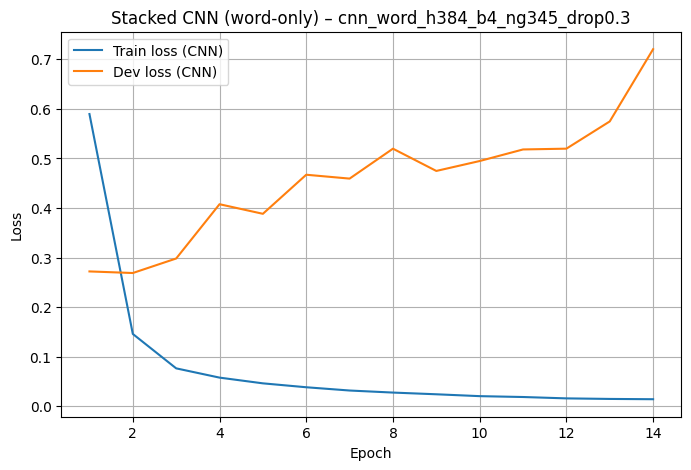

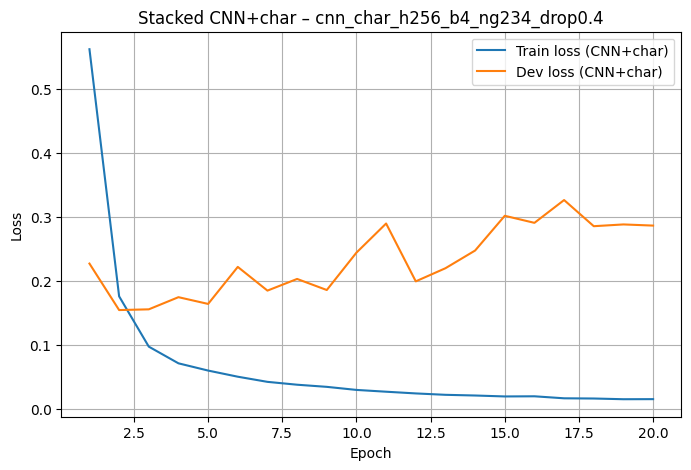

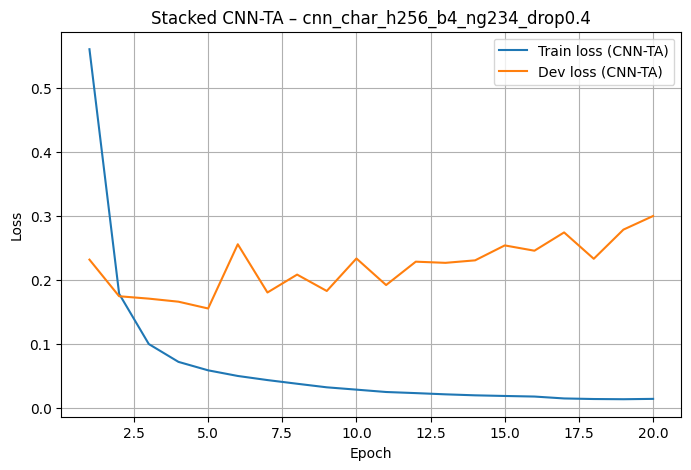

In [43]:
# ===== Plot loss curves for best CNN models =====

# word-only CNN
plt.figure(figsize=(8,5))
epochs = range(1, len(best_cnn_word_history["train_loss"])+1)
plt.plot(epochs, best_cnn_word_history["train_loss"], label="Train loss (CNN)")
plt.plot(epochs, best_cnn_word_history["dev_loss"],   label="Dev loss (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Stacked CNN (word-only) – {best_cnn_word_config['name']}")
plt.legend()
plt.grid(True)
plt.show()

# CNN+char
plt.figure(figsize=(8,5))
epochs = range(1, len(best_cnn_char_history["train_loss"])+1)
plt.plot(epochs, best_cnn_char_history["train_loss"], label="Train loss (CNN+char)")
plt.plot(epochs, best_cnn_char_history["dev_loss"],   label="Dev loss (CNN+char)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Stacked CNN+char – {best_cnn_char_config['name']}")
plt.legend()
plt.grid(True)
plt.show()

# CNN-TA
plt.figure(figsize=(8,5))
epochs = range(1, len(cnn_ta_history["train_loss"])+1)
plt.plot(epochs, cnn_ta_history["train_loss"], label="Train loss (CNN-TA)")
plt.plot(epochs, cnn_ta_history["dev_loss"],   label="Dev loss (CNN-TA)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Stacked CNN-TA – {best_cnn_char_config['name']}")
plt.legend()
plt.grid(True)
plt.show()


In [44]:
# ===== Evaluate CNN variants and extend comparison tables =====

eval_batch_size = 64

# loaders for word-only CNN
train_seq_loader_cnn = DataLoader(
    train_seq_dataset, batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences
)
dev_seq_loader_cnn = DataLoader(
    dev_seq_dataset,   batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences
)
test_seq_loader_cnn = DataLoader(
    test_seq_dataset,  batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences
)

# loaders for CNN+char / CNN-TA
train_seq_loader_cnn_char = DataLoader(
    train_seq_dataset_chars, batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences_with_chars
)
dev_seq_loader_cnn_char = DataLoader(
    dev_seq_dataset_chars,   batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences_with_chars
)
test_seq_loader_cnn_char = DataLoader(
    test_seq_dataset_chars,  batch_size=eval_batch_size,
    shuffle=False, collate_fn=collate_sentences_with_chars
)

# --- WORD-ONLY CNN ---
y_train_true_cnn, y_train_pred_cnn, y_train_proba_cnn = predict_seq_with_proba_cnn(
    best_cnn_word_model, train_seq_loader_cnn, device, use_chars=False
)
y_dev_true_cnn, y_dev_pred_cnn, y_dev_proba_cnn = predict_seq_with_proba_cnn(
    best_cnn_word_model, dev_seq_loader_cnn, device, use_chars=False
)
y_test_true_cnn, y_test_pred_cnn, y_test_proba_cnn = predict_seq_with_proba_cnn(
    best_cnn_word_model, test_seq_loader_cnn, device, use_chars=False
)

print("\n=== CNN (word-only) RESULTS ===")
evaluate_split_full("TRAIN (CNN)", y_train_true_cnn, y_train_pred_cnn, y_train_proba_cnn, idx2tag)
evaluate_split_full("DEV   (CNN)", y_dev_true_cnn,   y_dev_pred_cnn,   y_dev_proba_cnn,   idx2tag)
evaluate_split_full("TEST  (CNN)", y_test_true_cnn,  y_test_pred_cnn,  y_test_proba_cnn,  idx2tag)

# --- CNN + CHAR ---
y_train_true_cnn_char, y_train_pred_cnn_char, y_train_proba_cnn_char = predict_seq_with_proba_cnn(
    best_cnn_char_model, train_seq_loader_cnn_char, device, use_chars=True
)
y_dev_true_cnn_char, y_dev_pred_cnn_char, y_dev_proba_cnn_char = predict_seq_with_proba_cnn(
    best_cnn_char_model, dev_seq_loader_cnn_char, device, use_chars=True
)
y_test_true_cnn_char, y_test_pred_cnn_char, y_test_proba_cnn_char = predict_seq_with_proba_cnn(
    best_cnn_char_model, test_seq_loader_cnn_char, device, use_chars=True
)

print("\n=== CNN+char RESULTS ===")
evaluate_split_full("TRAIN (CNN+char)", y_train_true_cnn_char, y_train_pred_cnn_char, y_train_proba_cnn_char, idx2tag)
evaluate_split_full("DEV   (CNN+char)", y_dev_true_cnn_char,   y_dev_pred_cnn_char,   y_dev_proba_cnn_char,   idx2tag)
evaluate_split_full("TEST  (CNN+char)", y_test_true_cnn_char,  y_test_pred_cnn_char,  y_test_proba_cnn_char,  idx2tag)

# --- CNN-TA (temporal averaging) ---
y_train_true_cnn_ta, y_train_pred_cnn_ta, y_train_proba_cnn_ta = predict_seq_with_proba_cnn(
    cnn_ta_model, train_seq_loader_cnn_char, device, use_chars=True
)
y_dev_true_cnn_ta, y_dev_pred_cnn_ta, y_dev_proba_cnn_ta = predict_seq_with_proba_cnn(
    cnn_ta_model, dev_seq_loader_cnn_char, device, use_chars=True
)
y_test_true_cnn_ta, y_test_pred_cnn_ta, y_test_proba_cnn_ta = predict_seq_with_proba_cnn(
    cnn_ta_model, test_seq_loader_cnn_char, device, use_chars=True
)

print("\n=== CNN-TA RESULTS ===")
evaluate_split_full("TRAIN (CNN-TA)", y_train_true_cnn_ta, y_train_pred_cnn_ta, y_train_proba_cnn_ta, idx2tag)
evaluate_split_full("DEV   (CNN-TA)", y_dev_true_cnn_ta,   y_dev_pred_cnn_ta,   y_dev_proba_cnn_ta,   idx2tag)
evaluate_split_full("TEST  (CNN-TA)", y_test_true_cnn_ta,  y_test_pred_cnn_ta,  y_test_proba_cnn_ta,  idx2tag)


# ========= EXTEND THE TABLES =========

# TRAIN
train_rows = [
    make_results_row_from_preds("Baseline",          y_train_true_b,        y_train_pred_b,        y_train_proba_b,        idx2tag),
    make_results_row_from_preds("MLP (best config)", y_train_true_m,        y_train_pred_m,        y_train_proba_m,        idx2tag),
    make_results_row_from_preds("BiLSTM",            y_train_true_r,        y_train_pred_r,        y_train_proba_r,        idx2tag),
    make_results_row_from_preds("BiLSTM-char",       y_train_true_c,        y_train_pred_c,        y_train_proba_c,        idx2tag),
    make_results_row_from_preds("BiLSTM-TA",         y_train_true_ta,       y_train_pred_ta,       y_train_proba_ta,       idx2tag),
    make_results_row_from_preds("CNN",               y_train_true_cnn,      y_train_pred_cnn,      y_train_proba_cnn,      idx2tag),
    make_results_row_from_preds("CNN-char",          y_train_true_cnn_char, y_train_pred_cnn_char, y_train_proba_cnn_char, idx2tag),
    make_results_row_from_preds("CNN-TA",            y_train_true_cnn_ta,   y_train_pred_cnn_ta,   y_train_proba_cnn_ta,   idx2tag),
]
train_df = pd.DataFrame(train_rows)[cols]

# DEV
dev_rows = [
    make_results_row_from_preds("Baseline",          y_dev_true_b,        y_dev_pred_b,        y_dev_proba_b,        idx2tag),
    make_results_row_from_preds("MLP (best config)", y_dev_true_m,        y_dev_pred_m,        y_dev_proba_m,        idx2tag),
    make_results_row_from_preds("BiLSTM",            y_dev_true_r,        y_dev_pred_r,        y_dev_proba_r,        idx2tag),
    make_results_row_from_preds("BiLSTM-char",       y_dev_true_c,        y_dev_pred_c,        y_dev_proba_c,        idx2tag),
    make_results_row_from_preds("BiLSTM-TA",         y_dev_true_ta,       y_dev_pred_ta,       y_dev_proba_ta,       idx2tag),
    make_results_row_from_preds("CNN",               y_dev_true_cnn,      y_dev_pred_cnn,      y_dev_proba_cnn,      idx2tag),
    make_results_row_from_preds("CNN-char",          y_dev_true_cnn_char, y_dev_pred_cnn_char, y_dev_proba_cnn_char, idx2tag),
    make_results_row_from_preds("CNN-TA",            y_dev_true_cnn_ta,   y_dev_pred_cnn_ta,   y_dev_proba_cnn_ta,   idx2tag),
]
dev_df = pd.DataFrame(dev_rows)[cols]

# TEST
test_rows = [
    make_results_row_from_preds("Baseline",          y_test_true_b,        y_test_pred_b,        y_test_proba_b,        idx2tag),
    make_results_row_from_preds("MLP (best config)", y_test_true_m,        y_test_pred_m,        y_test_proba_m,        idx2tag),
    make_results_row_from_preds("BiLSTM",            y_test_true_r,        y_test_pred_r,        y_test_proba_r,        idx2tag),
    make_results_row_from_preds("BiLSTM-char",       y_test_true_c,        y_test_pred_c,        y_test_proba_c,        idx2tag),
    make_results_row_from_preds("BiLSTM-TA",         y_test_true_ta,       y_test_pred_ta,       y_test_proba_ta,       idx2tag),
    make_results_row_from_preds("CNN",               y_test_true_cnn,      y_test_pred_cnn,      y_test_proba_cnn,      idx2tag),
    make_results_row_from_preds("CNN-char",          y_test_true_cnn_char, y_test_pred_cnn_char, y_test_proba_cnn_char, idx2tag),
    make_results_row_from_preds("CNN-TA",            y_test_true_cnn_ta,   y_test_pred_cnn_ta,   y_test_proba_cnn_ta,   idx2tag),
]
test_df = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)



=== CNN (word-only) RESULTS ===

===== TRAIN (CNN) =====
Per-tag metrics:
Tag    ADJ | P=0.9923  R=0.9972  F1=0.9948  PR-AUC=0.9997
Tag    ADP | P=0.9983  R=0.9991  F1=0.9987  PR-AUC=1.0000
Tag    ADV | P=0.9952  R=0.9914  F1=0.9933  PR-AUC=0.9997
Tag    AUX | P=0.9997  R=0.9994  F1=0.9996  PR-AUC=1.0000
Tag  CCONJ | P=0.9911  R=0.9936  F1=0.9923  PR-AUC=0.9997
Tag    DET | P=0.9938  R=0.9933  F1=0.9936  PR-AUC=0.9998
Tag   INTJ | P=1.0000  R=0.9958  F1=0.9979  PR-AUC=1.0000
Tag   NOUN | P=0.9986  R=0.9980  F1=0.9983  PR-AUC=1.0000
Tag    NUM | P=0.9848  R=0.9986  F1=0.9916  PR-AUC=0.9999
Tag   PRON | P=0.9897  R=0.9901  F1=0.9899  PR-AUC=0.9995
Tag  PROPN | P=0.9968  R=0.9972  F1=0.9970  PR-AUC=0.9999
Tag  SCONJ | P=0.9890  R=0.9934  F1=0.9912  PR-AUC=0.9993
Tag   VERB | P=0.9991  R=0.9984  F1=0.9988  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9945
  Macro-R:       0.9958
  Macro-F1:      0.9951
  Macro-PR-AUC:  0.9998

===== DEV   (CNN) =====
Per-tag metrics:
Tag    ADJ | P=0

,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9957,0.9948,0.9953,0.9997,0.9983,0.9974,0.9978,1.0000,0.9957,...,0.9879,0.9992,0.9997,0.9999,0.9998,1.0000,0.9942,0.9953,0.9947,0.9997
2,BiLSTM,0.9931,0.9880,0.9906,0.9993,0.9912,0.9986,0.9948,0.9998,0.9874,...,0.9699,0.9923,0.9990,0.9992,0.9991,1.0000,0.9880,0.9879,0.9879,0.9984
3,BiLSTM-char,0.9935,0.9865,0.9900,0.9994,0.9944,0.9979,0.9961,0.9998,0.9908,...,0.9714,0.9937,0.9997,0.9987,0.9992,1.0000,0.9880,0.9879,0.9879,0.9986
4,BiLSTM-TA,0.9899,0.9927,0.9913,0.9995,0.9929,0.9972,0.9950,0.9998,0.9894,...,0.9662,0.9925,0.9997,0.9997,0.9997,1.0000,0.9882,0.9864,0.9873,0.9984
5,CNN,0.9923,0.9972,0.9948,0.9997,0.9983,0.9991,0.9987,1.0000,0.9952,...,0.9912,0.9993,0.9991,0.9984,0.9988,1.0000,0.9945,0.9958,0.9951,0.9998
6,CNN-char,0.9967,0.9968,0.9968,0.9999,0.9988,0.9999,0.9994,1.0000,0.9970,...,0.9925,0.9996,0.9999,0.9990,0.9995,1.0000,0.9961,0.9959,0.9960,0.9999
7,CNN-TA,0.9962,0.9986,0.9974,1.0000,0.9965,0.9998,0.9982,1.0000,0.9980,...,0.9860,0.9989,1.0000,0.9999,1.0000,1.0000,0.9935,0.9949,0.9942,0.9998



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9363,0.7257,0.8176,0.8923,0.9902,0.9892,0.9897,0.9988,0.9557,...,0.9109,0.9718,0.8246,0.9948,0.9017,0.9821,0.9509,0.9223,0.9339,0.9735
2,BiLSTM,0.9611,0.7119,0.8180,0.8880,0.9871,0.9935,0.9903,0.9990,0.9678,...,0.9302,0.9718,0.8266,0.9925,0.9020,0.9755,0.9512,0.9244,0.9352,0.9703
3,BiLSTM-char,0.7468,0.8903,0.8123,0.9260,0.9913,0.9935,0.9924,0.9997,0.9774,...,0.9326,0.9769,0.9556,0.9921,0.9735,0.9968,0.9487,0.9542,0.9506,0.9859
4,BiLSTM-TA,0.9460,0.7215,0.8187,0.8830,0.9881,0.9935,0.9908,0.9992,0.9728,...,0.9204,0.9721,0.8175,0.9978,0.8987,0.9806,0.9581,0.9232,0.9372,0.9734
5,CNN,0.9666,0.7147,0.8218,0.8493,0.9871,0.9946,0.9908,0.9987,0.9644,...,0.9237,0.9721,0.8070,0.9974,0.8922,0.9734,0.9564,0.9232,0.9362,0.9667
6,CNN-char,0.9090,0.8354,0.8706,0.9398,0.9849,0.9935,0.9892,0.9994,0.9729,...,0.9204,0.9652,0.9423,0.9959,0.9683,0.9938,0.9572,0.9534,0.9549,0.9852
7,CNN-TA,0.8729,0.8477,0.8601,0.9406,0.9861,0.9967,0.9914,0.9995,0.9817,...,0.9326,0.9782,0.9357,0.9963,0.9650,0.9955,0.9565,0.9551,0.9555,0.9880



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9545,0.7806,0.8588,0.9129,0.9910,0.9898,0.9904,0.9996,0.9579,...,0.9333,0.9843,0.8279,0.9932,0.9030,0.9786,0.9536,0.9318,0.9409,0.9753
2,BiLSTM,0.9729,0.7646,0.8563,0.9010,0.9877,0.9966,0.9921,0.9992,0.9733,...,0.9483,0.9840,0.8304,0.9916,0.9039,0.9708,0.9501,0.9309,0.9385,0.9720
3,BiLSTM-char,0.7456,0.9082,0.8189,0.9443,0.9932,0.9966,0.9949,0.9998,0.9771,...,0.9433,0.9854,0.9531,0.9868,0.9697,0.9959,0.9512,0.9575,0.9534,0.9870
4,BiLSTM-TA,0.9403,0.7753,0.8499,0.8979,0.9933,0.9977,0.9955,0.9994,0.9799,...,0.9522,0.9842,0.8230,0.9972,0.9017,0.9762,0.9586,0.9287,0.9413,0.9742
5,CNN,0.9696,0.7646,0.8550,0.8828,0.9899,0.9955,0.9927,0.9993,0.9651,...,0.9498,0.9833,0.8114,0.9972,0.8948,0.9733,0.9545,0.9298,0.9395,0.9713
6,CNN-char,0.8794,0.8630,0.8711,0.9503,0.9921,0.9955,0.9938,0.9998,0.9806,...,0.9417,0.9794,0.9415,0.9940,0.9670,0.9952,0.9586,0.9567,0.9574,0.9865
7,CNN-TA,0.8566,0.8896,0.8728,0.9530,0.9910,0.9966,0.9938,0.9999,0.9821,...,0.9567,0.9868,0.9340,0.9936,0.9629,0.9953,0.9587,0.9601,0.9591,0.9876


In [45]:
!pip -q install transformers accelerate

import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)
from sklearn.metrics import f1_score, accuracy_score

MODEL_NAME = "pranaydeeps/Ancient-Greek-BERT"
# MODEL_NAME = "google-bert/bert-base-multilingual-cased"
# MODEL_NAME = "nlpaueb/bert-base-greek-uncased-v1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [46]:
IGNORE_INDEX = -100
MAX_LEN = 512

def encode_sentence(words, tags):
    enc = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LEN
    )
    word_ids = enc.word_ids()
    labels = []
    prev = None
    for wi in word_ids:
        if wi is None:
            labels.append(IGNORE_INDEX)
        elif wi != prev:
            labels.append(tag2idx[tags[wi]])
        else:
            labels.append(IGNORE_INDEX)
        prev = wi
    enc["labels"] = labels
    return enc

class BertPosDataset(Dataset):
    def __init__(self, sents):
        self.encs = [encode_sentence(words, tags) for words, tags in sents]

    def __len__(self):
        return len(self.encs)

    def __getitem__(self, i):
        item = {k: torch.tensor(v) for k, v in self.encs[i].items()}
        return item

train_bert_ds = BertPosDataset(train_sents)
dev_bert_ds   = BertPosDataset(dev_sents)
test_bert_ds  = BertPosDataset(test_sents)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def truncation_indicator(sents):
    truncated = 0
    for words, _ in sents:
        enc = tokenizer(words, is_split_into_words=True, truncation=True, max_length=MAX_LEN, return_overflowing_tokens=True)
        # If overflowing_tokens exists and is non-empty -> truncation happened
        if "overflowing_tokens" in enc and len(enc["overflowing_tokens"]) > 0:
            truncated += 1
    return truncated, len(sents)

tr, tot = truncation_indicator(train_sents)
print(f"Train maxlen-hit indicator: {tr}/{tot} = {tr/tot:.2%}")


Train maxlen-hit indicator: 0/15016 = 0.00%


In [47]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    y_true, y_pred = [], []
    for p_seq, l_seq in zip(preds, labels):
        for p, l in zip(p_seq, l_seq):
            if l == IGNORE_INDEX:
                continue
            y_true.append(int(l))
            y_pred.append(int(p))

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
    }


In [48]:
import torch
import torch.nn as nn
from transformers import AutoConfig, AutoModel

class BertForTokenClassificationWithHead(nn.Module):
    """
    BERT encoder + configurable MLP head for token classification.
    - head_num_layers=0 -> linear classifier
    - head_num_layers>=1 -> (Linear+GELU+Dropout)* + final Linear
    """
    def __init__(self, model_name, num_labels,
                 head_hidden_dim=0,
                 head_num_layers=0,
                 head_dropout=0.1):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name, config=self.config)

        hidden_size = self.config.hidden_size
        self.num_labels = num_labels

        self.dropout = nn.Dropout(head_dropout)

        layers = []
        in_dim = hidden_size

        # Build an MLP head
        if head_num_layers > 0:
            if head_hidden_dim <= 0:
                raise ValueError("If head_num_layers > 0, head_hidden_dim must be > 0")

            for _ in range(head_num_layers):
                layers.append(nn.Linear(in_dim, head_hidden_dim))
                layers.append(nn.GELU())
                layers.append(nn.Dropout(head_dropout))
                in_dim = head_hidden_dim

        self.mlp = nn.Sequential(*layers) if layers else None
        self.classifier = nn.Linear(in_dim, num_labels)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids if token_type_ids is not None else None,
        )
        x = out.last_hidden_state  # [B, T, H]
        x = self.dropout(x)
        if self.mlp is not None:
            x = self.mlp(x)
        logits = self.classifier(x)  # [B, T, C]

        loss = None
        if labels is not None:
            # standard token-classification loss with ignore_index
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return {"loss": loss, "logits": logits}


In [49]:
def _get_bert_backbone(model: nn.Module):
    """
    Returns the encoder backbone module if possible.
    For our wrapper: model.bert is the backbone.
    """
    if hasattr(model, "bert"):
        return model.bert
    raise ValueError("Could not find backbone (expected attribute .bert).")

def freeze_bert_layers(model: nn.Module, freeze_n_encoder_layers=0, freeze_embeddings=False):
    """
    Freezes:
      - embeddings
      - first N encoder layers (bottom layers)
    """
    backbone = _get_bert_backbone(model)

    # Freeze embeddings
    if freeze_embeddings and hasattr(backbone, "embeddings"):
        for p in backbone.embeddings.parameters():
            p.requires_grad = False

    # Freeze bottom N encoder layers
    if freeze_n_encoder_layers > 0:
        if not hasattr(backbone, "encoder") or not hasattr(backbone.encoder, "layer"):
            raise ValueError("Backbone does not expose encoder.layer")

        layers = backbone.encoder.layer
        n = min(freeze_n_encoder_layers, len(layers))
        for i in range(n):
            for p in layers[i].parameters():
                p.requires_grad = False


In [50]:
import numpy as np
import pandas as pd
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def train_eval_one_bert_extended(run_name, cfg, seed=42):
    model = BertForTokenClassificationWithHead(
        model_name=MODEL_NAME,
        num_labels=len(tag2idx),
        head_hidden_dim=cfg["head_hidden_dim"],
        head_num_layers=cfg["head_num_layers"],
        head_dropout=cfg["head_dropout"],
    )

    # Freeze
    freeze_bert_layers(
        model,
        freeze_n_encoder_layers=cfg["freeze_n_encoder_layers"],
        freeze_embeddings=cfg["freeze_embeddings"],
    )

    args = TrainingArguments(
        output_dir=f"./runs/{run_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        learning_rate=cfg["lr"],
        per_device_train_batch_size=cfg["bs"],
        per_device_eval_batch_size=cfg["bs"],
        gradient_accumulation_steps=cfg.get("grad_accum", 1),

        num_train_epochs=cfg["num_epochs"],
        weight_decay=cfg["wd"],
        warmup_ratio=cfg.get("warmup_ratio", 0.0),
        lr_scheduler_type=cfg.get("scheduler", "linear"),

        max_grad_norm=cfg.get("max_grad_norm", 1.0),
        label_smoothing_factor=cfg.get("label_smoothing", 0.0),

        logging_strategy="epoch",
        report_to="none",
        fp16=False,
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_bert_ds,
        eval_dataset=dev_bert_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=cfg.get("early_stop_patience", 2))]
    )

    trainer.train()
    dev_metrics = trainer.evaluate(dev_bert_ds)
    return trainer, dev_metrics


In [51]:
grid = []

for freeze_n in [0, 4, 8]:
    for head in [
        {"head_num_layers": 0, "head_hidden_dim": 0},          # linear head
        {"head_num_layers": 1, "head_hidden_dim": 256},        # 1-layer MLP
        {"head_num_layers": 2, "head_hidden_dim": 256},        # 2-layer MLP
    ]:
        for lr in [2e-5, 3e-5]:
            for wd in [0.0, 0.01]:
                grid.append({
                    "freeze_n_encoder_layers": freeze_n,
                    "freeze_embeddings": False,

                    "head_num_layers": head["head_num_layers"],
                    "head_hidden_dim": head["head_hidden_dim"],
                    "head_dropout": 0.2,

                    "lr": lr,
                    "wd": wd,
                    "bs": 8,
                    "grad_accum": 1,

                    "warmup_ratio": 0.06,
                    "scheduler": "linear",
                    "label_smoothing": 0.0,

                    "max_grad_norm": 1.0,
                    "num_epochs": 10,
                    "early_stop_patience": 2,
                })


In [52]:
def _get_metric(metrics_dict, key):
    if key in metrics_dict:
        return metrics_dict[key]
    eval_key = f"eval_{key}"
    if eval_key in metrics_dict:
        return metrics_dict[eval_key]
    for k, v in metrics_dict.items():
        if k.endswith(key):
            return v
    raise KeyError(f"Could not find metric '{key}' in {list(metrics_dict.keys())}")

tuning_rows = []
best_trainer = None
best_cfg = None
best_score = -1.0

for i, cfg in enumerate(grid, start=1):
    run_name = f"bert_ext_{i}"
    tr, dev_m = train_eval_one_bert_extended(run_name, cfg, seed=42)

    dev_f1 = float(_get_metric(dev_m, "f1_macro"))
    dev_acc = float(_get_metric(dev_m, "accuracy"))

    row = {
        "run": run_name,
        "dev_f1_macro": dev_f1,
        "dev_acc": dev_acc,
        **cfg
    }
    tuning_rows.append(row)

    if dev_f1 > best_score:
        best_score = dev_f1
        best_trainer = tr
        best_cfg = cfg

tuning_df = pd.DataFrame(tuning_rows).sort_values("dev_f1_macro", ascending=False)
display(tuning_df.head(20))
print("BEST CONFIG:", best_cfg)
print("BEST DEV MACRO-F1:", best_score)


model.safetensors:   0%|          | 0.00/452M [00:00<?, ?B/s]

/tmp/ipython-input-1284125973.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,0.459800,0.081706,0.973777,0.969612,0.973777
2,0.071800,0.066251,0.980369,0.979225,0.980369
3,0.040300,0.068262,0.980223,0.979018,0.980223
4,0.025500,0.074850,0.983006,0.979345,0.983006
5,0.015300,0.088767,0.982933,0.978675,0.982933
6,0.009600,0.105946,0.981907,0.977930,0.981907


/tmp/ipython-input-1284125973.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,0.469000,0.077796,0.975461,0.971445,0.975461
2,0.070500,0.064779,0.980076,0.977581,0.980076
3,0.040100,0.067637,0.981248,0.978871,0.981248
4,0.025000,0.077220,0.982274,0.980029,0.982274
5,0.015500,0.088969,0.981541,0.978548,0.981541
6,0.008900,0.099942,0.982640,0.978090,0.982640


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,0.751400,0.101513,0.968503,0.962256,0.968503
2,0.108000,0.072276,0.977439,0.972918,0.977439
3,0.072200,0.069709,0.977805,0.973027,0.977805
4,0.052500,0.073435,0.979270,0.975003,0.979270
5,0.039700,0.078999,0.979051,0.973310,0.979051
6,0.030300,0.080968,0.979637,0.975513,0.979637
7,0.024400,0.089415,0.980589,0.976902,0.980589
8,0.018800,0.092754,0.981175,0.978522,0.981175
9,0.015600,0.096969,0.980735,0.977997,0.980735
10,0.013100,0.098565,0.981028,0.978029,0.981028


/tmp/ipython-input-1284125973.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro
1,0.748900,0.099215,0.968869,0.964210,0.968869
2,0.107400,0.072100,0.977073,0.974259,0.977073
3,0.071800,0.071123,0.977879,0.974718,0.977879
4,0.052800,0.073227,0.979344,0.975152,0.979344
5,0.038800,0.077218,0.979783,0.975301,0.979783
6,0.030100,0.083647,0.979417,0.975437,0.979417
7,0.024600,0.087631,0.981102,0.977741,0.981102
8,0.019300,0.091209,0.980882,0.978122,0.980882
9,0.015600,0.096389,0.981395,0.978362,0.981395
10,0.013700,0.098087,0.980882,0.978367,0.980882


,run,dev_f1_macro,dev_acc,freeze_n_encoder_layers,freeze_embeddings,head_num_layers,head_hidden_dim,head_dropout,lr,wd,bs,grad_accum,warmup_ratio,scheduler,label_smoothing,max_grad_norm,num_epochs,early_stop_patience
13,bert_ext_14,0.9811,0.9830,4,False,0,0,0.2000,0.0000,0.0100,8,1,0.0600,linear,0.0000,1.0000,10,2
20,bert_ext_21,0.9811,0.9827,4,False,2,256,0.2000,0.0000,0.0000,8,1,0.0600,linear,0.0000,1.0000,10,2
14,bert_ext_15,0.9810,0.9828,4,False,0,0,0.2000,0.0000,0.0000,8,1,0.0600,linear,0.0000,1.0000,10,2
22,bert_ext_23,0.9807,0.9818,4,False,2,256,0.2000,0.0000,0.0000,8,1,0.0600,linear,0.0000,1.0000,10,2
12,bert_ext_13,0.9803,0.9823,4,False,0,0,0.2000,0.0000,0.0000,8,1,0.0600,linear,0.0000,1.0000,10,2
17,bert_ext_18,0.9801,0.9822,4,False,1,256,0.2000,0.0000,0.0100,8,1,0.0600,linear,0.0000,1.0000,10,2
1,bert_ext_2,0.9800,0.9823,0,False,0,0,0.2000,0.0000,0.0100,8,1,0.0600,linear,0.0000,1.0000,10,2
23,bert_ext_24,0.9799,0.9813,4,False,2,256,0.2000,0.0000,0.0100,8,1,0.0600,linear,0.0000,1.0000,10,2
9,bert_ext_10,0.9797,0.9816,0,False,2,256,0.2000,0.0000,0.0100,8,1,0.0600,linear,0.0000,1.0000,10,2
4,bert_ext_5,0.9797,0.9811,0,False,1,256,0.2000,0.0000,0.0000,8,1,0.0600,linear,0.0000,1.0000,10,2


BEST CONFIG: {'freeze_n_encoder_layers': 4, 'freeze_embeddings': False, 'head_num_layers': 0, 'head_hidden_dim': 0, 'head_dropout': 0.2, 'lr': 2e-05, 'wd': 0.01, 'bs': 8, 'grad_accum': 1, 'warmup_ratio': 0.06, 'scheduler': 'linear', 'label_smoothing': 0.0, 'max_grad_norm': 1.0, 'num_epochs': 10, 'early_stop_patience': 2}
BEST DEV MACRO-F1: 0.9811474181214658


In [53]:
eval_logs = pd.DataFrame(best_trainer.state.log_history)
best_eval = eval_logs.dropna(subset=["eval_f1_macro"]).sort_values("eval_f1_macro", ascending=False).iloc[0]
best_epoch = best_eval["epoch"]
best_f1 = best_eval["eval_f1_macro"]
print("Best epoch:", best_epoch, "Best dev macro-F1:", best_f1)

Best epoch: 10.0 Best dev macro-F1: 0.9811474181214658


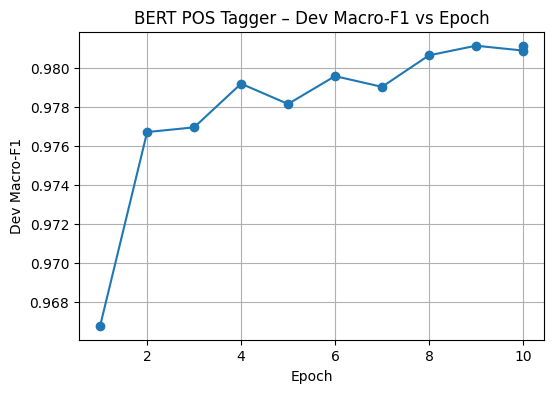

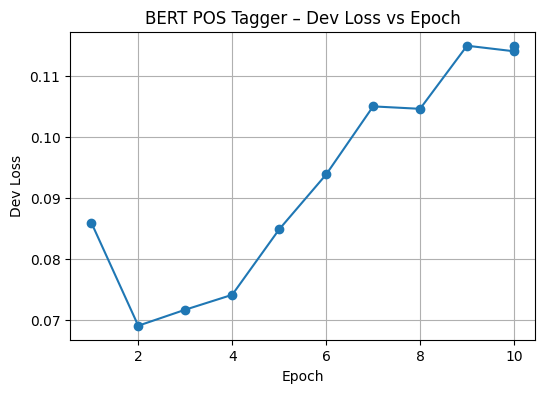

In [54]:
eval_logs = pd.DataFrame(best_trainer.state.log_history)
eval_logs = eval_logs[eval_logs["eval_f1_macro"].notna()]  # keep only eval rows

plt.figure(figsize=(6, 4))
plt.plot(eval_logs["epoch"], eval_logs["eval_f1_macro"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Dev Macro-F1")
plt.title("BERT POS Tagger – Dev Macro-F1 vs Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Dev Loss")
plt.title("BERT POS Tagger – Dev Loss vs Epoch")
plt.grid(True)
plt.show()

In [60]:
import numpy as np
import torch

def _softmax_np(x, axis=-1):
    # stable softmax in numpy
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def bert_preds_to_flat_arrays(trainer, dataset, ignore_index=-100):
    """
    Returns:
      y_true:  (N,) int
      y_pred:  (N,) int
      y_proba: (N, C) float32  where C = num_tags
    """
    out = trainer.predict(dataset)

    logits = out.predictions
    labels = out.label_ids

    if isinstance(logits, (tuple, list)):
        logits = logits[0]

    # logits: (B, T, C), labels: (B, T)
    logits = np.asarray(logits)
    labels = np.asarray(labels)

    # Mask out special tokens/subwords/padding
    mask = labels != ignore_index

    # Pred ids
    pred_ids = np.argmax(logits, axis=-1)

    # Probabilities
    probs = _softmax_np(logits, axis=-1).astype(np.float32)

    # Flatten with mask
    y_true = labels[mask].astype(int)
    y_pred = pred_ids[mask].astype(int)

    # For probs, expand mask to last dim then reshape
    y_proba = probs[mask]  # (N, C)

    return y_true, y_pred, y_proba


# 1) Get BERT predictions from the best trainer
y_train_true_bert, y_train_pred_bert, y_train_proba_bert = bert_preds_to_flat_arrays(
    best_trainer, train_bert_ds, ignore_index=IGNORE_INDEX
)
y_dev_true_bert,   y_dev_pred_bert,   y_dev_proba_bert   = bert_preds_to_flat_arrays(
    best_trainer, dev_bert_ds, ignore_index=IGNORE_INDEX
)
y_test_true_bert,  y_test_pred_bert,  y_test_proba_bert  = bert_preds_to_flat_arrays(
    best_trainer, test_bert_ds, ignore_index=IGNORE_INDEX
)

# 2) Append rows to tables
bert_name = f"BERT ({MODEL_NAME.split('/')[-1]})"

train_row = make_results_row_from_preds(
    bert_name, y_train_true_bert, y_train_pred_bert, y_train_proba_bert, idx2tag
)
dev_row = make_results_row_from_preds(
    bert_name, y_dev_true_bert, y_dev_pred_bert, y_dev_proba_bert, idx2tag
)
test_row = make_results_row_from_preds(
    bert_name, y_test_true_bert, y_test_pred_bert, y_test_proba_bert, idx2tag
)

train_df = pd.concat([train_df, pd.DataFrame([train_row])[cols]], ignore_index=True)
dev_df   = pd.concat([dev_df,   pd.DataFrame([dev_row])[cols]],   ignore_index=True)
test_df  = pd.concat([test_df,  pd.DataFrame([test_row])[cols]],  ignore_index=True)

print("=== TRAIN RESULTS (updated) ===")
display(train_df)

print("\n=== DEV RESULTS (updated) ===")
display(dev_df)

print("\n=== TEST RESULTS (updated) ===")
display(test_df)

=== TRAIN RESULTS (updated) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP (best config),0.9957,0.9948,0.9953,0.9997,0.9983,0.9974,0.9978,1.0000,0.9957,...,0.9879,0.9992,0.9997,0.9999,0.9998,1.0000,0.9942,0.9953,0.9947,0.9997
2,BiLSTM,0.9931,0.9880,0.9906,0.9993,0.9912,0.9986,0.9948,0.9998,0.9874,...,0.9699,0.9923,0.9990,0.9992,0.9991,1.0000,0.9880,0.9879,0.9879,0.9984
3,BiLSTM-char,0.9935,0.9865,0.9900,0.9994,0.9944,0.9979,0.9961,0.9998,0.9908,...,0.9714,0.9937,0.9997,0.9987,0.9992,1.0000,0.9880,0.9879,0.9879,0.9986
4,BiLSTM-TA,0.9899,0.9927,0.9913,0.9995,0.9929,0.9972,0.9950,0.9998,0.9894,...,0.9662,0.9925,0.9997,0.9997,0.9997,1.0000,0.9882,0.9864,0.9873,0.9984
5,CNN,0.9923,0.9972,0.9948,0.9997,0.9983,0.9991,0.9987,1.0000,0.9952,...,0.9912,0.9993,0.9991,0.9984,0.9988,1.0000,0.9945,0.9958,0.9951,0.9998
6,CNN-char,0.9967,0.9968,0.9968,0.9999,0.9988,0.9999,0.9994,1.0000,0.9970,...,0.9925,0.9996,0.9999,0.9990,0.9995,1.0000,0.9961,0.9959,0.9960,0.9999
7,CNN-TA,0.9962,0.9986,0.9974,1.0000,0.9965,0.9998,0.9982,1.0000,0.9980,...,0.9860,0.9989,1.0000,0.9999,1.0000,1.0000,0.9935,0.9949,0.9942,0.9998
8,BERT (Ancient-Greek-BERT),0.9999,0.9999,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,0.9999,...,0.9997,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9999,0.9999,1.0000



=== DEV RESULTS (updated) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP (best config),0.9363,0.7257,0.8176,0.8923,0.9902,0.9892,0.9897,0.9988,0.9557,...,0.9109,0.9718,0.8246,0.9948,0.9017,0.9821,0.9509,0.9223,0.9339,0.9735
2,BiLSTM,0.9611,0.7119,0.8180,0.8880,0.9871,0.9935,0.9903,0.9990,0.9678,...,0.9302,0.9718,0.8266,0.9925,0.9020,0.9755,0.9512,0.9244,0.9352,0.9703
3,BiLSTM-char,0.7468,0.8903,0.8123,0.9260,0.9913,0.9935,0.9924,0.9997,0.9774,...,0.9326,0.9769,0.9556,0.9921,0.9735,0.9968,0.9487,0.9542,0.9506,0.9859
4,BiLSTM-TA,0.9460,0.7215,0.8187,0.8830,0.9881,0.9935,0.9908,0.9992,0.9728,...,0.9204,0.9721,0.8175,0.9978,0.8987,0.9806,0.9581,0.9232,0.9372,0.9734
5,CNN,0.9666,0.7147,0.8218,0.8493,0.9871,0.9946,0.9908,0.9987,0.9644,...,0.9237,0.9721,0.8070,0.9974,0.8922,0.9734,0.9564,0.9232,0.9362,0.9667
6,CNN-char,0.9090,0.8354,0.8706,0.9398,0.9849,0.9935,0.9892,0.9994,0.9729,...,0.9204,0.9652,0.9423,0.9959,0.9683,0.9938,0.9572,0.9534,0.9549,0.9852
7,CNN-TA,0.8729,0.8477,0.8601,0.9406,0.9861,0.9967,0.9914,0.9995,0.9817,...,0.9326,0.9782,0.9357,0.9963,0.9650,0.9955,0.9565,0.9551,0.9555,0.9880
8,BERT (Ancient-Greek-BERT),0.9732,0.9465,0.9597,0.9845,0.9935,0.9935,0.9935,0.9989,0.9789,...,0.9688,0.9827,0.9977,0.9959,0.9968,0.9999,0.9799,0.9825,0.9811,0.9935



=== TEST RESULTS (updated) ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP (best config),0.9545,0.7806,0.8588,0.9129,0.9910,0.9898,0.9904,0.9996,0.9579,...,0.9333,0.9843,0.8279,0.9932,0.9030,0.9786,0.9536,0.9318,0.9409,0.9753
2,BiLSTM,0.9729,0.7646,0.8563,0.9010,0.9877,0.9966,0.9921,0.9992,0.9733,...,0.9483,0.9840,0.8304,0.9916,0.9039,0.9708,0.9501,0.9309,0.9385,0.9720
3,BiLSTM-char,0.7456,0.9082,0.8189,0.9443,0.9932,0.9966,0.9949,0.9998,0.9771,...,0.9433,0.9854,0.9531,0.9868,0.9697,0.9959,0.9512,0.9575,0.9534,0.9870
4,BiLSTM-TA,0.9403,0.7753,0.8499,0.8979,0.9933,0.9977,0.9955,0.9994,0.9799,...,0.9522,0.9842,0.8230,0.9972,0.9017,0.9762,0.9586,0.9287,0.9413,0.9742
5,CNN,0.9696,0.7646,0.8550,0.8828,0.9899,0.9955,0.9927,0.9993,0.9651,...,0.9498,0.9833,0.8114,0.9972,0.8948,0.9733,0.9545,0.9298,0.9395,0.9713
6,CNN-char,0.8794,0.8630,0.8711,0.9503,0.9921,0.9955,0.9938,0.9998,0.9806,...,0.9417,0.9794,0.9415,0.9940,0.9670,0.9952,0.9586,0.9567,0.9574,0.9865
7,CNN-TA,0.8566,0.8896,0.8728,0.9530,0.9910,0.9966,0.9938,0.9999,0.9821,...,0.9567,0.9868,0.9340,0.9936,0.9629,0.9953,0.9587,0.9601,0.9591,0.9876
8,BERT (Ancient-Greek-BERT),0.9579,0.9681,0.9630,0.9916,0.9955,0.9977,0.9966,0.9995,0.9766,...,0.9725,0.9942,0.9988,0.9952,0.9970,0.9998,0.9804,0.9828,0.9815,0.9947


In [61]:
# ============================================================
# OPTIONAL BONUS: LLM prompting on 10 test examples + evaluation
# ============================================================
# What this cell does:
# 1) Samples 10 test sentences.
# 2) Builds a clean, parseable prompt (optionally few-shot) we paste into an LLM.
# 4) We paste the LLM's output back into `llm_output` and compute Accuracy + Macro-F1.
# ============================================================

import random
import re
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

RANDOM_SEED = 42
N_TEST = 10
N_FEWSHOT = 2  # set to 0 if you want zero-shot

random.seed(RANDOM_SEED)

# ---------- TSV formatting ----------
def sent_to_tsv(words, tags=None):
    if tags is None:
        return "\n".join([f"{w}\t_" for w in words])
    return "\n".join([f"{w}\t{t}" for w, t in zip(words, tags)])

# ---------- 1) Pick few-shot demonstrations from TRAIN ----------
fewshot = random.sample(train_sents, N_FEWSHOT) if N_FEWSHOT > 0 else []

# ---------- 2) Pick 10 test sentences ----------
test_sample = random.sample(test_sents, N_TEST)

# ---------- 3) Build the prompt ----------
# Output contract:
# - For each sentence, output EXACTLY the same number of lines as input tokens
# - Each line: WORD<TAB>UPOS
# - Sentences separated by a blank line
# - Start each sentence block with: "# sent_id = k"

tag_set_str = ", ".join([idx2tag[i] for i in range(len(idx2tag))])

prompt_parts = []
prompt_parts.append(
f"""You are a POS tagger for Ancient Greek (Universal Dependencies UPOS tags).
Choose one UPOS tag per token from this set:
{tag_set_str}

OUTPUT FORMAT:
- For each sentence, output a block that starts with: # sent_id = k
- Then output one line per token: WORD<TAB>UPOS
- Do NOT change tokens.
- Do NOT add extra tokens.
- Sentences must be separated by exactly one blank line.
- Do NOT output anything else (no explanations).

Example:"""
)

# Few-shot examples
for i, (w, t) in enumerate(fewshot, start=1):
    prompt_parts.append(f"\n# sent_id = demo_{i}\n" + sent_to_tsv(w, t) + "\n")

prompt_parts.append("\nNow tag the following sentences:\n")

# The actual test items (ground truths)
for k, (words, tags) in enumerate(test_sample, start=1):
    prompt_parts.append(f"# sent_id = {k}\n" + sent_to_tsv(words, tags=None) + "\n")

llm_prompt = "\n".join(prompt_parts).strip()

print("========== Copy and Paste this prompt into an LLM ==========\n")
print(llm_prompt[:4000])
if len(llm_prompt) > 4000:
    print("\n[Prompt truncated in printout due to length. It's stored in variable `llm_prompt` fully.]")
print("\n=========================================================\n")

# ---------- 4) Paste LLM output here (after running the prompt in an LLM) ----------
llm_output = r"""# sent_id = 1
χρόνου	NOUN
δὲ ADV
ἐπιγινομένου VERB
καὶ CCONJ
κατεστραμμένων VERB
σχεδὸν ADV
πάντων PRON
τῶν DET
ἐντὸς ADP
Ἅλυος PROPN
ποταμοῦ NOUN
οἰκημένων VERB
πλὴν ADP
γὰρ ADV
Κιλίκων PROPN
καὶ CCONJ
Λυκίων PROPN
τοὺς DET
ἄλλους ADJ
πάντας ADJ
ὑπ’ ADP
ἑωυτῷ PRON
εἶχε VERB
καταστρεψάμενος VERB
ὁ DET
Κροῖσος PROPN

# sent_id = 2
μακάριοι ADJ
οἱ DET
πεινῶντες VERB
νῦν ADV
ὅτι SCONJ
χορτασθήσεσθε VERB

# sent_id = 3
καὶ CCONJ
ἤδη ADV
ὥρας NOUN
πολλῆς ADJ
γινομένης VERB
προσελθόντες VERB
οἱ DET
μαθηταὶ NOUN
αὐτοῦ PRON
ἔλεγον VERB
ὅτι SCONJ
ἔρημός ADJ
ἐστιν AUX
ὁ DET
τόπος NOUN
καὶ CCONJ
ἤδη ADV
ὥρα NOUN
πολλή ADJ

# sent_id = 4
οὐχ ADV
οὗτός PRON
ἐστιν AUX
ὁ DET
τέκτων NOUN
ὁ DET
υἱὸς NOUN
τῆς DET
Μαρίας PROPN
καὶ CCONJ
ἀδελφὸς NOUN
Ἰακώβου PROPN
καὶ CCONJ
Ἰωσῆτος PROPN
καὶ CCONJ
Ἰούδα PROPN
καὶ CCONJ
Σίμωνος PROPN

# sent_id = 5
ὁ DET
δὲ ADV
ἀνάγων VERB
ἑκάστοτε ADV
ἐπὶ ADP
κέρας NOUN
τὰς DET
νέας ADJ
ὅκως SCONJ
τοῖσι DET
ἐρέτῃσι NOUN
χρήσαιτο VERB
διέκπλοον NOUN
ποιεύμενος VERB
τῇσι DET
νηυσὶ NOUN
δι’ ADP
ἀλληλέων PRON
καὶ CCONJ
τοὺς DET
ἐπιβάτας NOUN
ὁπλίσειε VERB
τὸ DET
λοιπὸν ADJ
τῆς DET
ἡμέρης NOUN
τὰς DET
νέας ADJ
ἔχεσκε VERB
ἐπ’ ADP
ἀγκυρέων NOUN
παρεῖχέ VERB
τε CCONJ
τοῖσι DET
Ἴωσι PROPN
πόνον NOUN
δι’ ADP
ἡμέρης NOUN

# sent_id = 6
μοῦνος ADJ
δὲ ADV
Εὐρυλέων PROPN
τῶν DET
συγκτιστέων NOUN
περιεγένετο VERB
τούτου PRON
τοῦ DET
πάθεος NOUN

# sent_id = 7
ἀνδραγαθίη NOUN
δὲ ADV
αὕτη PRON
ἀποδέδεκται VERB
μετὰ ADP
τὸ DET
μάχεσθαι VERB
εἶναι VERB
ἀγαθόν ADJ
ὃς PRON
ἂν ADV
πολλοὺς ADJ
ἀποδέξῃ VERB
παῖδας NOUN

# sent_id = 8
καὶ CCONJ
μετοικιῶ VERB
ὑμᾶς PRON
ἐπέκεινα ADP
Βαβυλῶνος PROPN

# sent_id = 9
εἶπαν VERB
οἱ DET
Μάγοι NOUN

# sent_id = 10
ἔστι AUX
τε CCONJ
ὁ DET
παῖς NOUN
καὶ CCONJ
περίεστι VERB
καί CCONJ
μιν PRON
ἐπ’ ADP
ἀγροῦ NOUN
διαιτώμενον VERB
οἱ DET
ἐκ ADP
τῆς DET
κώμης NOUN
παῖδες NOUN
ἐστήσαντο VERB
βασιλέα NOUN
""".strip()

# ---------- 5) Parse + Evaluate ----------
def parse_llm_output(output_text, expected_sentences, valid_tags):
    start = output_text.find("# sent_id")
    if start == -1:
        raise ValueError("No '# sent_id = k' headers found in LLM output.")
    output_text = output_text[start:].strip()

    blocks = re.split(r"\n\s*\n", output_text, flags=re.MULTILINE)
    preds_by_sent = {}

    for block in blocks:
        lines = [ln.strip() for ln in block.splitlines() if ln.strip() != ""]
        if not lines:
            continue
        if not lines[0].startswith("# sent_id"):
            raise ValueError(f"Each block must start with '# sent_id = k'. Problem block:\n{block}")

        m = re.search(r"#\s*sent_id\s*=\s*(\S+)", lines[0])
        if not m:
            raise ValueError(f"Could not parse sent_id line: {lines[0]}")
        sid = m.group(1)

        tag_lines = lines[1:]
        pred_tags = []
        pred_words = []

        for ln in tag_lines:
            ln = ln.replace("\u200b", "").strip()  # remove zero-width spaces

            # Accept WORD<TAB>TAG or WORD TAG
            if "\t" in ln:
                w, t = ln.split("\t", 1)
            else:
                parts = re.split(r"\s+", ln)
                if len(parts) < 2:
                    raise ValueError(f"Line must be WORD<TAB>TAG or WORD TAG. Problem line: {ln}")
                w, t = parts[0], parts[1]

            w = w.strip()
            t = t.strip()

            pred_words.append(w)
            pred_tags.append(t)

            if t not in valid_tags:
                raise ValueError(f"Invalid UPOS tag '{t}' in sent_id={sid}.")

        preds_by_sent[sid] = (pred_words, pred_tags)

    # Align with expected_sentences
    out_pred_seqs = []
    for k, (gold_words, gold_tags) in enumerate(expected_sentences, start=1):
        sid = str(k)
        if sid not in preds_by_sent:
            raise ValueError(f"Missing prediction block for '# sent_id = {sid}'")

        pred_words, pred_tags = preds_by_sent[sid]
        if len(pred_words) != len(gold_words):
            raise ValueError(
                f"Token count mismatch in sent_id={sid}: expected {len(gold_words)} tokens, got {len(pred_words)}."
            )

        for gw, pw in zip(gold_words, pred_words):
            if gw != pw:
                raise ValueError(
                    f"Token mismatch in sent_id={sid}. Expected '{gw}' but got '{pw}'."
                )

        out_pred_seqs.append(pred_tags)

    return out_pred_seqs


# Only evaluate if placeholder is replaced
if "PASTE\tYOURTAG" in llm_output or "..." in llm_output:
    print("You still have placeholder text in `llm_output`.\n"
          "1) Copy the prompt above into an LLM UI.\n"
          "2) Paste the LLM response into `llm_output` exactly.\n"
          "3) Re-run this cell to compute results.")
else:
    valid_tags = set(tag2idx.keys())

    pred_tag_seqs = parse_llm_output(llm_output, test_sample, valid_tags)

    # Flatten and score
    gold_flat = []
    pred_flat = []
    for (words, gold_tags), pred_tags in zip(test_sample, pred_tag_seqs):
        gold_flat.extend(gold_tags)
        pred_flat.extend(pred_tags)

    acc = accuracy_score(gold_flat, pred_flat)
    macro_f1 = f1_score(gold_flat, pred_flat, average="macro", zero_division=0)

    print("===== LLM RESULTS (10 test sentences) =====")
    print(f"Tokens evaluated: {len(gold_flat)}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Macro-F1:  {macro_f1:.4f}")
    print("=================================================")

    # per-sentence quick summary
    for i, ((words, gold_tags), pred_tags) in enumerate(zip(test_sample, pred_tag_seqs), start=1):
        sent_acc = accuracy_score(gold_tags, pred_tags)
        print(f"sent_id={i:02d}  tokens={len(words):3d}  accuracy={sent_acc:.4f}")


========== Copy and Paste this prompt into an LLM ==========

You are a POS tagger for Ancient Greek (Universal Dependencies UPOS tags).
Choose one UPOS tag per token from this set:
ADJ, ADP, ADV, AUX, CCONJ, DET, INTJ, NOUN, NUM, PRON, PROPN, SCONJ, VERB

OUTPUT FORMAT:
- For each sentence, output a block that starts with: # sent_id = k
- Then output one line per token: WORD<TAB>UPOS
- Do NOT change tokens.
- Do NOT add extra tokens.
- Sentences must be separated by exactly one blank line.
- Do NOT output anything else (no explanations).

Example:

# sent_id = demo_1
καὶ	CCONJ
τοῦτο	PRON
εἰπὼν	VERB
ἔδειξεν	VERB
τὰς	DET
χεῖρας	NOUN
καὶ	CCONJ
τὴν	DET
πλευρὰν	NOUN
αὐτοῖς	PRON


# sent_id = demo_2
ἐπειρήθη	VERB
δὲ	ADV
καὶ	ADV
τοὺς	DET
ἐν	ADP
τῇ	DET
λίμνῃ	NOUN
κατοικημένους	VERB
ἐξαιρέειν	VERB
ὧδε	ADV


Now tag the following sentences:

# sent_id = 1
χρόνου	_
δὲ	_
ἐπιγινομένου	_
καὶ	_
κατεστραμμένων	_
σχεδὸν	_
πάντων	_
τῶν	_
ἐντὸς	_
Ἅλυος	_
ποταμοῦ	_
οἰκημένων	_
πλὴν	_
γὰρ	_
Κιλίκων	_
καὶ	